In [0]:
import os
import re
import json
import cv2
import pytesseract
import pandas as pd
import logging
from PIL import Image

# =============================================================================
# Logging Configuration & Utilities
# =============================================================================
class ExcludeLogsFilter(logging.Filter):
    """Filter out unwanted log messages."""
    def filter(self, record):
        exclude_keywords = [
            "spark.databricks.clusterUsageTags.sparkVersion",
            "Answer received",
            "Command to send"
        ]
        return not any(kw in record.getMessage() for kw in exclude_keywords)

def configure_logger(debug: bool = False, log_file: str = "logs/application.log") -> logging.Logger:
    os.makedirs(os.path.dirname(log_file), exist_ok=True)
    logger = logging.getLogger("PipelineLogger")
    logger.setLevel(logging.DEBUG if debug else logging.INFO)
    # Remove any existing handlers.
    for handler in logger.handlers[:]:
        logger.removeHandler(handler)
    formatter = logging.Formatter("%(asctime)s %(levelname)-8s %(message)s")
    # File Handler
    fh = logging.FileHandler(log_file)
    fh.setFormatter(formatter)
    fh.addFilter(ExcludeLogsFilter())
    logger.addHandler(fh)
    # Stream Handler
    ch = logging.StreamHandler()
    ch.setFormatter(formatter)
    ch.addFilter(ExcludeLogsFilter())
    logger.addHandler(ch)
    return logger

# Global logger instance; set debug to True if needed.
logger = configure_logger(debug=False)

# =============================================================================
# Shared Utility Classes
# =============================================================================
class FileUtils:
    """Utilities for handling file paths."""
    @staticmethod
    def dbfs_to_local_path(dbfs_path: str) -> str:
        if dbfs_path.startswith("dbfs:/"):
            local_path = os.path.join("/dbfs", dbfs_path[len("dbfs:/"):].lstrip("/"))
            return local_path
        return dbfs_path

    @staticmethod
    def sanitize_section_name(section: str) -> str:
        return section.lower().replace(" ", "_").replace("/", "_").replace(":", "")

class ImageUtils:
    """Image loading, preprocessing and OCR helper methods."""
    @staticmethod
    def safe_read_image(image_path: str):
        local_path = FileUtils.dbfs_to_local_path(image_path)
        logger.info(f"Reading image from: {local_path}")
        if not os.path.exists(local_path):
            logger.error(f"File not found: {local_path}")
            raise FileNotFoundError(f"File not found: {local_path}")
        img = cv2.imread(local_path)
        if img is None:
            logger.error(f"Failed to read image at: {local_path}")
            raise ValueError(f"Failed to read image at: {local_path}")
        return img

    @staticmethod
    def safe_read_image_pil(image_path: str) -> Image.Image:
        local_path = FileUtils.dbfs_to_local_path(image_path)
        logger.info(f"Reading image with PIL from: {local_path}")
        if not os.path.exists(local_path):
            logger.error(f"File not found: {local_path}")
            raise FileNotFoundError(f"File not found: {local_path}")
        return Image.open(local_path)

    @staticmethod
    def preprocess_image(img, debug: bool = False):
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        thresh = cv2.adaptiveThreshold(
            gray, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY, 15, 9
        )
        if debug:
            import matplotlib.pyplot as plt
            plt.figure(figsize=(8, 8))
            plt.imshow(thresh, cmap="gray")
            plt.title("Thresholded Image")
            plt.axis("off")
            plt.show()
        return thresh

    @staticmethod
    def perform_ocr(image, config="--psm 6") -> str:
        text = pytesseract.image_to_string(image, config=config)
        return text.strip()
    
    @staticmethod
    def detect_text_regions(thresh_img, debug: bool = False):
        contours, _ = cv2.findContours(thresh_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        rois = []
        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            if w > 30 and h > 15:
                rois.append((x, y, w, h))
        rois.sort(key=lambda b: (b[1], b[0]))
        if debug and rois:
            img_copy = cv2.cvtColor(thresh_img, cv2.COLOR_GRAY2BGR)
            for (x, y, w, h) in rois:
                cv2.rectangle(img_copy, (x, y), (x+w, y+h), (0, 255, 0), 2)
            import matplotlib.pyplot as plt
            plt.figure(figsize=(10, 10))
            plt.imshow(img_copy)
            plt.title("Detected Text Regions")
            plt.axis("off")
            plt.show()
        return rois

    @staticmethod
    def perform_ocr_on_rois(img, rois, debug: bool = False):
        results = []
        for (x, y, w, h) in rois:
            roi = img[y:y+h, x:x+w]
            text = pytesseract.image_to_string(roi, config="--psm 6").strip() or "[BLANK]"
            results.append((x, y, w, h, text))
            if debug:
                logger.debug(f"OCR result for ROI ({x}, {y}, {w}, {h}): {text}")
        return results

# =============================================================================
# OCR Grouping Function
# =============================================================================
def group_ocr_rows(roi_results, y_threshold=20):
    """
    Group OCR results based on their vertical positions.
    Each item in roi_results is a tuple: (x, y, w, h, text).
    """
    rois_with_center = [(x, y, w, h, text, y + h/2) for (x, y, w, h, text) in roi_results]
    rois_with_center.sort(key=lambda r: r[5])
    groups = []
    current_group = []
    current_center = None

    for (x, y, w, h, text, center) in rois_with_center:
        if current_center is None or abs(center - current_center) <= y_threshold:
            current_group.append((x, y, w, h, text))
            current_center = center if current_center is None else (current_center + center) / 2
        else:
            groups.append(current_group)
            current_group = [(x, y, w, h, text)]
            current_center = center
    if current_group:
        groups.append(current_group)
    return groups

# =============================================================================
# Pipeline Classes
# =============================================================================

class DailyDrillingReportPipeline:
    """Processes the Daily Drilling Report section."""
    @staticmethod
    def process(image_path: str, debug: bool = False):
        img = ImageUtils.safe_read_image(image_path)
        # Crop region (modify coordinates as necessary).
        x, y, w, h = 1600, 0, 950, 185
        cropped = img[y:y+h, x:x+w]
        gray = cropped if len(cropped.shape) == 2 else cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
        equalized = cv2.equalizeHist(gray)
        blurred = cv2.GaussianBlur(equalized, (5, 5), 0)
        processed = cv2.adaptiveThreshold(blurred, 255,
                                          cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                          cv2.THRESH_BINARY, 11, 2)
        ocr_text = pytesseract.image_to_string(processed, config="--psm 6").strip()
        logger.info("Daily Drilling Report OCR extraction complete.")

        # Extract keys using regex.
        expected_keys = ["Report Date", "Report Num", "Rig"]
        combined = " ".join(ocr_text.splitlines()).strip()
        combined = re.sub(r'\s+', ' ', combined)
        extracted = {}
        for i, key in enumerate(expected_keys):
            if i < len(expected_keys) - 1:
                pattern = rf'{re.escape(key)}\s*:\s*(.*?)(?=\s*{re.escape(expected_keys[i+1])}\s*:|$)'
            else:
                pattern = rf'{re.escape(key)}\s*:\s*(.*)'
            match = re.search(pattern, combined, re.IGNORECASE)
            extracted[key] = match.group(1).strip() if (match and match.group(1).strip()) else None

        df = pd.DataFrame(list(extracted.items()), columns=["Key", "Value"])
        return {"DAILY DRILLING REPORT": extracted}, df

class WellJobInfoPipeline:
    """Processes the Well/Job information section."""
    @staticmethod
    def process(image_path: str, debug: bool = False):
        img = ImageUtils.safe_read_image(image_path)
        ocr_text = pytesseract.image_to_string(img, config="--psm 6").strip()
        expected_keys = [
            "Well Name", "Job Name", "Supervisor(s)", "Field", "Sec/Twn/Rng",
            "Phone", "AFE #", "API #", "Email", "Contractor", "Elevation",
            "RKB", "Spud Date", "Days from Spud", "Days on Loc", "MD/TVD",
            "24 Hr Footage", "Present Operations", "Activity Planned"
        ]
        combined = " ".join(ocr_text.splitlines()).strip()
        combined = re.sub(r'\s+', ' ', combined)
        result = {}
        for i, key in enumerate(expected_keys):
            if i < len(expected_keys) - 1:
                pattern = rf'{re.escape(key)}\s*:\s*(.*?)(?=\s*{re.escape(expected_keys[i+1])}\s*:|$)'
            else:
                pattern = rf'{re.escape(key)}\s*:\s*(.*)'
            match = re.search(pattern, combined, re.IGNORECASE)
            result[key] = match.group(1).strip() if match else ""
        df = pd.DataFrame(list(result.items()), columns=["Key", "Value"])
        logger.info("Well/Job Information processed.")
        return {"WELL/JOB INFORMATION": result}, df

class MudPipeline:
    """Processes the Mud section."""
    @staticmethod
    def process(image_path: str, debug: bool = False):
        img = ImageUtils.safe_read_image(image_path)
        thresh_img = ImageUtils.preprocess_image(img, debug=debug)
        rois = ImageUtils.detect_text_regions(thresh_img, debug=debug)
        roi_texts = ImageUtils.perform_ocr_on_rois(img, rois, debug=debug)
        # Build mud data using tokens.
        expected_headers = [
            "Type", "Weight In", "Weight Out", "pH", "CAKE",
            "GELS (10s/10m/30m)", "Oil/Water", "FV", "ES", "PV",
            "YP", "CL", "Ca", "LGS", "WL", "HTHP Loss", "3 RPM",
            "6 RPM", "Mud Pits and Hole Volume", "24 Hr Loss",
            "Total Loss", "Comments"
        ]
        mud_dict = MudPipeline.build_mud_dict_from_rois(roi_texts, expected_headers)
        df = pd.DataFrame(list(mud_dict.items()), columns=["Key", "Value"]) if isinstance(mud_dict, dict) \
             else pd.DataFrame(mud_dict)
        logger.info("Mud section processed.")
        return {"MUD": mud_dict}, df

    @staticmethod
    def build_mud_dict_from_rois(roi_texts, expected_headers):
        row_tolerance = 10
        rows = []
        current_row = []
        prev_y = None
        for (x, y, w, h, text) in roi_texts:
            if prev_y is None or abs(y - prev_y) <= row_tolerance:
                current_row.append((x, y, w, h, text))
            else:
                rows.append(current_row)
                current_row = [(x, y, w, h, text)]
            prev_y = y
        if current_row:
            rows.append(current_row)

        row_strings = [" ".join([cell[4] for cell in sorted(row, key=lambda cell: cell[0])])
                       for row in rows]

        # Identify header and data rows.
        header1_line = None
        value1_line = None
        header2_line = None
        value2_line = None
        for i, r_text in enumerate(row_strings):
            if "type" in r_text.lower() and not header1_line:
                header1_line = r_text
                if i+1 < len(row_strings):
                    value1_line = row_strings[i+1]
            elif header1_line and not header2_line and any(kw in r_text.lower() for kw in ["rpm", "mud", "loss", "comments"]):
                header2_line = r_text
                if i+1 < len(row_strings):
                    value2_line = row_strings[i+1]
                break

        if value1_line is None:
            logger.error("No data row found for Mud section!")
            return {}

        tokens1 = value1_line.split()
        tokens2 = value2_line.split() if value2_line else []
        combined_tokens = tokens1 + tokens2
        return MudPipeline.parse_value_row_tokens(expected_headers, combined_tokens)

    @staticmethod
    def parse_value_row_tokens(expected_headers, tokens):
        # Adjust token count.
        expected_token_count = (len(expected_headers) - 1) + 3
        if len(tokens) < expected_token_count:
            tokens += [""] * (expected_token_count - len(tokens))
        elif len(tokens) > expected_token_count:
            tokens = tokens[:expected_token_count]
        result = {}
        idx = 0
        for header in expected_headers:
            if header == "GELS (10s/10m/30m)":
                gels_tokens = tokens[idx:idx+3]
                result[header] = {"10s": gels_tokens[0], "10m": gels_tokens[1], "30m": gels_tokens[2]}
                idx += 3
            else:
                result[header] = tokens[idx]
                idx += 1
        return result

class SurveyDataPipeline:
    """Processes the Survey Data section."""
    @staticmethod
    def process(image_path: str, debug: bool = False):
        img = ImageUtils.safe_read_image(image_path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        thresh = cv2.adaptiveThreshold(
            gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY, 15, 9
        )
        rois = ImageUtils.detect_text_regions(thresh, debug=debug)
        roi_texts = []
        for (x, y, w, h) in rois:
            roi = img[y:y+h, x:x+w]
            text = pytesseract.image_to_string(roi, config="--psm 6").strip() or ""
            roi_texts.append((x, y, w, h, text))
        groups = group_ocr_rows(roi_texts, y_threshold=10)
        survey_list = []
        for group in groups:
            group.sort(key=lambda cell: cell[0])
            tokens = [cell[4] for cell in group]
            if len(tokens) >= 5:
                survey_list.append({
                    "MD": tokens[0],
                    "Inclination": tokens[1],
                    "Azimuth": tokens[2],
                    "DLS": tokens[3],
                    "TVD": tokens[4]
                })
        df = pd.DataFrame(survey_list)
        logger.info("Survey Data processed.")
        return {"SURVEY DATA": survey_list}, df

class CostDataPipeline:
    """Processes the Cost section."""
    @staticmethod
    def process(image_path: str, debug: bool = False):
        img = ImageUtils.safe_read_image(image_path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        ocr_text = pytesseract.image_to_string(gray, config="--psm 6")
        logger.info("Cost OCR extraction complete.")
        expected_keys = [
            "Drilling AFE Amount", "Daily Drilling Cost", "Cumulative Drilling Cost",
            "Cumulative Well Cost", "Daily Mud Cost", "Cumulative Mud Cost"
        ]
        combined = " ".join(ocr_text.splitlines()).strip()
        combined = re.sub(r'\s+', ' ', combined)
        extracted = {}
        for i, key in enumerate(expected_keys):
            if i < len(expected_keys) - 1:
                pattern = rf'{re.escape(key)}\s*:\s*(.*?)(?=\s*{re.escape(expected_keys[i+1])}\s*:|$)'
            else:
                pattern = rf'{re.escape(key)}\s*:\s*(.*)'
            match = re.search(pattern, combined, re.IGNORECASE)
            extracted[key] = match.group(1).strip() if (match and match.group(1).strip()) else "[Blank]"
        df = pd.DataFrame(list(extracted.items()), columns=["Key", "Value"])
        logger.info("Cost data processed.")
        return {"COST DATA": extracted}, df

class ObsIntPipeline:
    """Processes the Observation & Intervention section."""
    @staticmethod
    def build_obs_int_data(roi_texts):
        tokens = []
        for (_, _, _, _, text) in roi_texts:
            for line in re.split(r'\n+', text):
                token = line.strip()
                if token and token.lower() not in {"daily numbers: observation & intervention", "number"}:
                    tokens.append(token)
        expected_types = ["Stop Cards", "Hazard ID's", "JSA's", "Permit to Work", "Totals"]
        # Remove header tokens and try to assign numbers.
        numbers = [t for t in tokens if re.match(r'^\d+(\.\d+)?$', t)]
        # Adjust list to match expected_types.
        while len(numbers) < len(expected_types):
            numbers.append("")
        numbers = numbers[:len(expected_types)]
        records = [{"Type": etype, "Number": num} for etype, num in zip(expected_types, numbers)]
        df = pd.DataFrame(records)
        logger.info("Observation & Intervention data processed.")
        return records, df

    @staticmethod
    def process(image_path: str, debug: bool = False):
        img = ImageUtils.safe_read_image(image_path)
        thresh = ImageUtils.preprocess_image(img, debug=debug)
        rois = ImageUtils.detect_text_regions(thresh, debug=debug)
        roi_texts = ImageUtils.perform_ocr_on_rois(img, rois, debug=debug)
        records, df = ObsIntPipeline.build_obs_int_data(roi_texts)
        return {"DAILY NUMBERS: OBSERVATION & INTERVENTION": records}, df

class PersonnelPipeline:
    """Processes the Personnel section."""
    @staticmethod
    def preprocess_personnel_data(groups):
        personnel_data = []
        header_lines = {"personnel", "company contractor no. personnel daily hours cumulative hours", "ssn"}
        for group in groups:
            row_text = group.strip()
            if row_text.lower() in header_lines:
                continue
            tokens = row_text.split()
            company_tokens = []
            for token in tokens:
                try:
                    float(token)
                    break
                except ValueError:
                    company_tokens.append(token)
            company = " ".join(company_tokens)
            numeric_tokens = re.findall(r'\d+(?:\.\d+)?', row_text)
            if len(numeric_tokens) < 3:
                continue
            try:
                no_personnel = int(float(numeric_tokens[-3]))
                daily_hours = int(float(numeric_tokens[-2]))
                cumulative_hours = int(float(numeric_tokens[-1]))
            except Exception:
                continue
            personnel_data.append({
                "Company": company,
                "Contractor": "Service Company",
                "No. Personnel": no_personnel,
                "Daily Hours": daily_hours,
                "Cumulative Hours": cumulative_hours
            })
        return {"PERSONNEL": personnel_data}

    @staticmethod
    def process(image_path: str, debug: bool = False):
        # Use ImageUtils to call the shared OCR functions.
        img = ImageUtils.safe_read_image(image_path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                       cv2.THRESH_BINARY, 11, 2)
        rois = ImageUtils.detect_text_regions(thresh, debug=debug)
        roi_results = ImageUtils.perform_ocr_on_rois(img, rois, debug=debug)
        groups = [ " ".join([text for (_, _, _, _, text) in group]) for group in group_ocr_rows(roi_results, y_threshold=20)]
        data_dict = PersonnelPipeline.preprocess_personnel_data(groups)
        df = pd.DataFrame(data_dict["PERSONNEL"]) if data_dict.get("PERSONNEL") else pd.DataFrame(
            columns=["Company", "Contractor", "No. Personnel", "Daily Hours", "Cumulative Hours"]
        )
        logger.info("Personnel data processed.")
        return data_dict, df

class BHAPipeline:
    """Processes the BHA section."""
    @staticmethod
    def extract_bha_data(image_path: str):
        image = ImageUtils.safe_read_image_pil(image_path)
        ocr_text = pytesseract.image_to_string(image)
        patterns = {
            "Drill Pipe Detail": r"Drill Pipe Detail:\s*([^\n]+)",
            "Size": r"Size:\s*([\d.]+)\b",
            "Wt./Ft": r"Wt\./Ft:\s*([\d.]+)\b",
            "Connection": r"Connection:\s*([\w\d-]+)\b",
            "ID": r"ID:\s*([\d.]+)\b",
            "Drill Bit": r"Drill Bit:\s*([^\n;]+)",
            "Motor": r"Motor:\s*([^\n;]+)",
            "MWD Tool": r"MWD Tool:\s*([^\n;]+)",
            "Monel Collar": r"Monel Collar:\s*([^\n;]+)",
            "X-Over": r"X-Over:\s*([^\n;]+)",
            "Sub": r"Sub:\s*([^\n;]+)",
            "HWDP": r"HWDP:\s*([^\n;]+)",
            "Drill Pipe": r"Drill Pipe:\s*([\d.]+(?:\" DP)?)",
            "Reamer": r"Reamer:\s*([^\n;]+)",
            "Shock Sub": r"Shock Sub:\s*([^\n;]+)",
            "Total Length": r"Total Length:\s*(\d+)\b"
        }
        bha_data = {}
        for key, pat in patterns.items():
            match = re.search(pat, ocr_text)
            if match:
                bha_data[key] = match.group(1).strip()
        # Cleanup Drill Pipe Detail if needed.
        if "Drill Pipe Detail" in bha_data:
            detail = bha_data["Drill Pipe Detail"]
            for rem in ["Size", "Wt./Ft", "Connection", "ID"]:
                if rem in bha_data:
                    detail = re.sub(rf"{rem}:\s*{re.escape(bha_data[rem])}", "", detail).strip(",; ")
            bha_data["Drill Pipe Detail"] = detail
        structured = {
            "BHA": {
                "Drill Pipe Detail": bha_data.get("Drill Pipe Detail", ""),
                "Size": bha_data.get("Size", ""),
                "Wt./Ft": bha_data.get("Wt./Ft", ""),
                "Connection": bha_data.get("Connection", ""),
                "ID": bha_data.get("ID", ""),
                "BHA #4": {
                    "Drill Bit": bha_data.get("Drill Bit", ""),
                    "Motor": bha_data.get("Motor", ""),
                    "MWD Tool": bha_data.get("MWD Tool", ""),
                    "Monel Collar": bha_data.get("Monel Collar", ""),
                    "X-Over": bha_data.get("X-Over", ""),
                    "Sub": bha_data.get("Sub", ""),
                    "HWDP": bha_data.get("HWDP", ""),
                    "Drill Pipe": bha_data.get("Drill Pipe", ""),
                    "Reamer": bha_data.get("Reamer", ""),
                    "Shock Sub": bha_data.get("Shock Sub", "")
                },
                "Total Length": bha_data.get("Total Length", "")
            }
        }
        return structured

    @staticmethod
    def process(image_path: str, debug: bool = False):
        bha_json = BHAPipeline.extract_bha_data(image_path)
        df = pd.json_normalize(bha_json["BHA"])
        logger.info("BHA data processed.")
        return {"BHA": bha_json["BHA"]}, df

class DirInfoPipeline:
    """Processes the Direction Information section."""
    @staticmethod
    def process(image_path: str, debug: bool = False):
        img = ImageUtils.safe_read_image(image_path)
        thresh = ImageUtils.preprocess_image(img, debug=debug)
        rois = ImageUtils.detect_text_regions(thresh, debug=debug)
        roi_texts = ImageUtils.perform_ocr_on_rois(img, rois, debug=debug)
        data, df = DirInfoPipeline.build_dir_info(roi_texts)
        logger.info("Direction Information processed.")
        return data, df

    @staticmethod
    def build_dir_info(roi_texts, debug: bool = False):
        all_texts = [t[4] for t in roi_texts]
        daily_cum_idx = next((i for i, txt in enumerate(all_texts)
                              if "daily" in txt.lower() and "cumulative" in txt.lower()), None)
        if daily_cum_idx is None:
            logger.warning("Could not locate 'Daily Cumulative' box.")
            return {}, pd.DataFrame()
        cat_idx = daily_cum_idx + 1
        if cat_idx >= len(all_texts):
            logger.warning("No bounding box after 'Daily Cumulative'.")
            return {}, pd.DataFrame()
        categories_box = all_texts[cat_idx]
        lines = [ln.strip() for ln in categories_box.split("\n") if ln.strip()]
        if len(lines) < 5:
            logger.warning(f"Expected at least 5 category lines, got {len(lines)}.")
        def safe_get(idx):
            return all_texts[idx] if 0 <= idx < len(all_texts) else ""
        structured = []
        for i in range(4):
            cat_name = lines[i] if i < len(lines) else f"Unknown Category {i+1}"
            daily_box = safe_get(cat_idx + 1 + (i * 2))
            cum_box = safe_get(cat_idx + 2 + (i * 2))
            structured.append({
                "Category": cat_name,
                "Daily": daily_box,
                "Cumulative": cum_box
            })
        # Process last category separately.
        last_box = safe_get(cat_idx + 9)
        last_cat = lines[4] if len(lines) >= 5 else "Rotating Footage"
        tokens = last_box.replace(last_cat, "").split() if last_box else []
        daily_val = tokens[0] if len(tokens) >= 2 else ""
        cum_val = tokens[1] if len(tokens) >= 2 else ""
        structured.append({
            "Category": last_cat,
            "Daily": daily_val,
            "Cumulative": cum_val if cum_val != "]" else ""
        })
        df = pd.DataFrame(structured)
        return {"DIR INFO": structured}, df

class DrillBitsPipeline:
    """Processes the Drill Bits section."""
    @staticmethod
    def build_drill_bits_info(roi_texts, debug: bool = False):
        row_tolerance = 10
        grouped_rows = []
        current_row = []
        prev_y = None
        for (x, y, w, h, text) in roi_texts:
            if prev_y is None or abs(y - prev_y) <= row_tolerance:
                current_row.append((x, y, w, h, text))
            else:
                grouped_rows.append(current_row)
                current_row = [(x, y, w, h, text)]
            prev_y = y
        if current_row:
            grouped_rows.append(current_row)
        row_strings = []
        for i, row in enumerate(grouped_rows):
            row.sort(key=lambda cell: cell[0])
            line = " ".join(cell[4] for cell in row).replace("\n", " ").strip()
            row_strings.append(line)
            if debug:
                logger.info(f"Drill Bits Row {i}: {line}")
        if len(row_strings) < 3:
            logger.warning("Not enough rows for Drill Bits layout.")
            return []
        data_lines = row_strings[3:]
        final_columns = [
            "Bit #", "Size", "Make", "Model", "Serial #",
            "Nozzle-(Number x Size)", "Nozzle-TFA",
            "Depth-In", "Depth-Out", "Depth-Feet", "Depth-ROP",
            "Hours-Total", "Hours-On Btm",
            "Dull Grade-I", "Dull Grade-O1", "Dull Grade-D", "Dull Grade-L", 
            "Dull Grade-B", "Dull Grade-G", "Dull Grade-O2", "Dull Grade-RP"
        ]
        structured_data = []
        for line in data_lines:
            tokens = line.split()
            if len(tokens) < len(final_columns):
                tokens += [""] * (len(final_columns) - len(tokens))
            elif len(tokens) > len(final_columns):
                tokens = tokens[:len(final_columns)]
            row_dict = {final_columns[i]: tokens[i] for i in range(len(final_columns))}
            structured_data.append(row_dict)
            if debug:
                logger.info(f"Drill Bits Parsed row: {row_dict}")
        return structured_data

    @staticmethod
    def process(image_path: str, debug: bool = False):
        img = ImageUtils.safe_read_image(image_path)
        thresh = ImageUtils.preprocess_image(img, debug=debug)
        rois = ImageUtils.detect_text_regions(thresh, debug=debug)
        roi_texts = ImageUtils.perform_ocr_on_rois(img, rois, debug=debug)
        drill_bits = DrillBitsPipeline.build_drill_bits_info(roi_texts, debug=debug)
        logger.info("Drill Bits processed.")
        # Return None for the dataframe if not needed.
        return {"DRILL BITS": drill_bits}, None

class ConsumablesPipeline:
    """Processes the Consumables section."""
    @staticmethod
    def group_rois_by_row(roi_results, threshold: int = 20):
        roi_with_center = [(x, y, w, h, text, y + h/2) for (x, y, w, h, text) in roi_results]
        roi_with_center.sort(key=lambda r: r[5])
        groups = []
        current_group = []
        current_center = None
        for (x, y, w, h, text, y_center) in roi_with_center:
            if current_center is None or abs(y_center - current_center) < threshold:
                current_group.append(text)
                current_center = y_center if current_center is None else (current_center + y_center) / 2
            else:
                groups.append(" ".join(current_group))
                current_group = [text]
                current_center = y_center
        if current_group:
            groups.append(" ".join(current_group))
        return groups

    @staticmethod
    def build_consumables_dict_from_rois(roi_texts, debug: bool = False):
        groups = ConsumablesPipeline.group_rois_by_row(roi_texts, threshold=20)
        data_rows = []
        for line in groups:
            line_str = line.strip()
            if ("consumable" in line_str.lower() and "received" in line_str.lower()) or "nun" in line_str.lower():
                continue
            if len(line_str.split()) < 5:
                continue
            data_rows.append(line_str)
        consumables_list = []
        for line in data_rows:
            tokens = re.split(r'\s+', line)
            if len(tokens) > 5:
                first = " ".join(tokens[:-4])
                tokens = [first] + tokens[-4:]
            if len(tokens) != 5:
                continue
            consumables_list.append({
                "Consumable": tokens[0],
                "Daily Received (gal)": tokens[1],
                "Daily Used (gal)": tokens[2],
                "Cumulative Used (gal)": tokens[3],
                "Daily on Hand (gal)": tokens[4]
            })
        return consumables_list

    @staticmethod
    def process(image_path: str, debug: bool = False):
        img = ImageUtils.safe_read_image(image_path)
        thresh = ImageUtils.preprocess_image(img, debug=debug)
        rois = ImageUtils.detect_text_regions(thresh, debug=debug)
        roi_texts = ImageUtils.perform_ocr_on_rois(img, rois, debug=debug)
        consumables_list = ConsumablesPipeline.build_consumables_dict_from_rois(roi_texts, debug=debug)
        df = pd.DataFrame(consumables_list)
        logger.info("Consumables data processed.")
        return {"CONSUMABLES": consumables_list}, df

class CasingPipeline:
    """Processes the Casing section."""
    @staticmethod
    def build_casing_dict_from_rois(roi_texts, expected_headers, debug=False):
        grouped_rows = group_ocr_rows(roi_texts, y_threshold=20)
        casing_rows = []
        for group in grouped_rows:
            row_string = " ".join([text for (x, y, w, h, text) in sorted(group, key=lambda item: item[0])]).strip()
            # Skip header rows (assumed to contain both "type" and "size")
            if "type" in row_string.lower() and "size" in row_string.lower():
                continue
            tokens = re.split(r'\s{2,}', row_string)
            if len(tokens) == 1:
                tokens = row_string.split()
            if len(tokens) < len(expected_headers):
                continue
            tokens = tokens[:len(expected_headers)]
            row_dict = {expected_headers[i]: tokens[i] for i in range(len(expected_headers))}
            casing_rows.append(row_dict)
        return casing_rows

    @staticmethod
    def process(image_path: str, debug: bool = False):
        img = ImageUtils.safe_read_image(image_path)
        thresh = ImageUtils.preprocess_image(img, debug=debug)
        rois = ImageUtils.detect_text_regions(thresh, debug=debug)
        roi_texts = ImageUtils.perform_ocr_on_rois(img, rois, debug=debug)
        expected_headers = ["Type", "Size", "Weight", "Grade", "Connection", "Top MD", "Bottom MD", "TOC"]
        casing_data = CasingPipeline.build_casing_dict_from_rois(roi_texts, expected_headers, debug=debug)
        df = pd.DataFrame(casing_data)
        logger.info("Casing data processed.")
        return {"CASING": casing_data}, df



In [0]:

def safe_read_image_bop(image_path: str):
    """
    Top-level function to read an image using OpenCV.
    """
    local_path = FileUtils.dbfs_to_local_path(image_path)
    logger.info(f"Reading image from: {local_path}")
    if not os.path.exists(local_path):
        raise FileNotFoundError(f"File not found: {local_path}")
    img = cv2.imread(local_path)
    if img is None:
        raise ValueError(f"OpenCV failed to load image: {local_path}")
    return img #

def safe_read_image_pil_bop(image_path: str) -> Image.Image:
    local_path = FileUtils.dbfs_to_local_path(image_path)
    logger.info(f"Reading image (PIL) from: {local_path}")
    if not os.path.exists(local_path):
        raise FileNotFoundError(f"File not found: {local_path}")
    return Image.open(local_path) #

def perform_ocr_bop(img, config="--psm 6") -> str:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    text = pytesseract.image_to_string(gray, config=config)
    return text.strip() #

def group_ocr_rows_bop(roi_results, y_threshold=20):
    """
    Group OCR result bounding boxes by their y-coordinate.
    """
    rois_with_center = [(x, y, w, h, text, y + h/2) for (x, y, w, h, text) in roi_results]
    rois_with_center.sort(key=lambda r: r[5])
    groups = []
    current_group = []
    current_center = None
    for (x, y, w, h, text, center) in rois_with_center:
        if current_center is None:
            current_group.append((x, y, w, h, text))
            current_center = center
        elif abs(center - current_center) <= y_threshold:
            current_group.append((x, y, w, h, text))
            current_center = (current_center + center) / 2
        else:
            groups.append(current_group)
            current_group = [(x, y, w, h, text)]
            current_center = center
    if current_group:
        groups.append(current_group)
    return groups

class ImageUtils_bop:
    """Shared image utilities."""
    @staticmethod
    def safe_read_image_bop(image_path: str):
        return safe_read_image_bop(image_path) #
    
    @staticmethod
    def safe_read_image_pil_bop(image_path: str) -> Image.Image:
        return safe_read_image_pil_bop(image_path)#

    @staticmethod
    def preprocess_image_bop(img, debug: bool = False):
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        thresh = cv2.adaptiveThreshold(
            gray, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY, 15, 9
        )
        return thresh #

    @staticmethod
    def detect_text_regions_bop(thresh_img, debug: bool = False):
        contours, _ = cv2.findContours(thresh_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        rois = []
        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            if w > 30 and h > 15:
                rois.append((x, y, w, h))
        rois.sort(key=lambda b: (b[1], b[0]))
        return rois

    @staticmethod
    def perform_ocr_on_rois_bop(img, rois, debug: bool = False):
        results = []
        for (x, y, w, h) in rois:
            roi = img[y:y+h, x:x+w]
            text = pytesseract.image_to_string(roi, config="--psm 6").strip() or "[BLANK]"
            results.append((x, y, w, h, text))
            if debug:
                logger.debug(f"OCR result at ({x}, {y}, {w}, {h}): {text}")
        return results

# =============================================================================
# BOP Pipeline (Reused Shared Functions)
# =============================================================================
class BOPPipeline:
    @staticmethod
    def extract_bop_info_bop(text: str) -> dict:
        patterns = {
            "Last BOP Test Date": r"Last BOP Test Date\s*:\s*(\d{1,2}/\d{1,2}/\d{2,4})",
            "Last BOP Drill": r"Last BOP Drill\s*:\s*(\d{1,2}/\d{1,2}/\d{2,4})",
            "Next BOP Test": r"Next BOP Test\s*:\s*(\d{1,2}/\d{1,2}/\d{2,4})"
        }
        result = {}
        for key, regex in patterns.items():
            match = re.search(regex, text, re.IGNORECASE)
            result[key] = match.group(1) if match else ""
        return result

    @staticmethod
    def process_bop(image_path: str, debug: bool = False) -> (dict, pd.DataFrame):
        logger.info(f"BOPPipeline: Processing image '{image_path}'")
        # Use the top-level safe_read_image defined above.
        img = safe_read_image_bop(image_path)
        ocr_text = perform_ocr_bop(img, config="--psm 6")
        if debug:
            logger.debug(f"BOPPipeline OCR Text:\n{ocr_text}")
        bop_info = BOPPipeline.extract_bop_info_bop(ocr_text)
        for key, value in bop_info.items():
            if value:
                logger.info(f"BOPPipeline: {key} -> {value}")
            else:
                logger.warning(f"BOPPipeline: {key} not found in OCR text.")
        df = pd.DataFrame(list(bop_info.items()), columns=["Key", "Value"])
        logger.info("BOPPipeline: Processing complete.")
        return {"BOP": bop_info}, df



In [0]:
import os
import re
import cv2
import json
import logging
import numpy as np
import pytesseract
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Helper: Convert DBFS paths to local paths
# -----------------------------------------------------------------------------
def dbfs_to_local_path(dbfs_path: str) -> str:
    if dbfs_path.startswith("dbfs:/"):
        return "/dbfs" + dbfs_path.replace("dbfs:", "")
    return dbfs_path

# -----------------------------------------------------------------------------
# (Optional) Helper: Display image (for debugging only)
# -----------------------------------------------------------------------------
def show_image(title: str, img, size=(10,10), cmap=None):
    plt.figure(figsize=size)
    plt.title(title)
    if cmap:
        plt.imshow(img, cmap=cmap)
    else:
        if len(img.shape) == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

# -----------------------------------------------------------------------------
# PumpsPipeline Class: encapsulates all Pumps section processing logic.
# -----------------------------------------------------------------------------
class PumpsPipeline:
    @staticmethod
    def enhance_image(img: np.ndarray) -> np.ndarray:
        """Enhance image for OCR: convert to grayscale, equalize, and apply bilateral filtering."""
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        eq = cv2.equalizeHist(gray)
        filtered = cv2.bilateralFilter(eq, d=9, sigmaColor=75, sigmaSpace=75)
        return filtered

    @staticmethod
    def binarize_image(img: np.ndarray) -> (np.ndarray, np.ndarray):
        """Return both Otsu and adaptive thresholded images."""
        _, otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        adaptive = cv2.adaptiveThreshold(img, 255, 
                                         cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                         cv2.THRESH_BINARY, 15, 10)
        return otsu, adaptive

    @staticmethod
    def detect_rows_via_morph_ops(img: np.ndarray, debug: bool = False) -> list:
        """Detect row boundaries via morphological operations."""
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
        morph = cv2.morphologyEx(bw, cv2.MORPH_OPEN, kernel, iterations=2)
        inv = cv2.bitwise_not(morph)
        contours, _ = cv2.findContours(inv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        boxes = []
        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            if w > 50 and h < 20:
                boxes.append((x, y, w, h))
        boxes.sort(key=lambda b: b[1])
        # Derive full row boundaries from the y coordinates.
        y_coords = []
        for (x, y, w, h) in boxes:
            y_coords.append(y)
            y_coords.append(y+h)
        y_coords = sorted(list(set(y_coords)))
        h_img, w_img = gray.shape
        if y_coords[0] > 5:
            y_coords.insert(0, 0)
        if abs(y_coords[-1] - h_img) > 5:
            y_coords.append(h_img)
        row_boxes = []
        for i in range(len(y_coords) - 1):
            if y_coords[i+1] - y_coords[i] >= 10:
                row_boxes.append((0, y_coords[i], w_img, y_coords[i+1]-y_coords[i]))
        if debug:
            print(f"Detected {len(row_boxes)} rows via morphology.")
        return row_boxes

    @staticmethod
    def ocr_on_rows(img: np.ndarray, row_boxes: list, debug: bool = False) -> list:
        """Perform OCR on each detected row (using --psm 6) and return the list of text strings."""
        texts = []
        for (x, y, w, h) in row_boxes:
            roi = img[y:y+h, x:x+w]
            gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
            _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            pil_roi = Image.fromarray(bw)
            text = pytesseract.image_to_string(pil_roi, config="--psm 6").strip()
            texts.append(text)
        return texts

    @staticmethod
    def multi_psm_ocr(roi: np.ndarray, debug: bool = False) -> str:
        """Run OCR on ROI using multiple PSM modes (6 and 11) and return the best result."""
        enhanced = PumpsPipeline.enhance_image(roi)
        otsu, _ = PumpsPipeline.binarize_image(enhanced)
        pil_img = Image.fromarray(otsu)
        psm_modes = ["6", "11"]
        results = {}
        for mode in psm_modes:
            config = f"--psm {mode}"
            text = pytesseract.image_to_string(pil_img, config=config).strip()
            lines = [l for l in text.splitlines() if l.strip()]
            results[mode] = (text, lines)
        best_mode = max(psm_modes, key=lambda m: sum(1 for l in results[m][1] if l.strip() and l.strip()[0].isdigit()))
        return results[best_mode][0]

    @staticmethod
    def segment_rows_via_projection(roi: np.ndarray, debug: bool = False) -> list:
        """Segment ROI into rows via horizontal projection."""
        gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        proj = np.sum(binary, axis=1)
        gap_thresh = np.max(proj) * 0.2
        gap_indices = np.where(proj < gap_thresh)[0]
        if len(gap_indices) == 0:
            pil_img = Image.fromarray(binary)
            return [pytesseract.image_to_string(pil_img, config="--psm 7").strip()]
        gap_segments = []
        start = gap_indices[0]
        prev = gap_indices[0]
        for idx in gap_indices[1:]:
            if idx - prev > 1:
                gap_segments.append((start, prev))
                start = idx
            prev = idx
        gap_segments.append((start, prev))
        boundaries = [int((s+e)//2) for s, e in gap_segments]
        boundaries = [0] + boundaries + [binary.shape[0]]
        row_texts = []
        for i in range(len(boundaries)-1):
            r1, r2 = boundaries[i], boundaries[i+1]
            if r2 - r1 < 10:
                continue
            row_img = roi[r1:r2, :]
            pil_row = Image.fromarray(row_img)
            text = pytesseract.image_to_string(pil_row, config="--psm 7").strip()
            if text:
                row_texts.append(text)
        return row_texts

    @staticmethod
    def split_block_to_sections(block_text: str) -> (list, list):
        """
        Split the combined OCR block into pump and drilling sections.
        Lines containing drilling keywords are filtered out of the pump section.
        """
        lines = [l.strip() for l in block_text.splitlines() if l.strip()]
        pump_lines = []
        drilling_lines = []
        section = None
        for line in lines:
            low = line.lower()
            if "drilling/circ" in low:
                section = "drilling"
                drilling_lines.append(line)
                continue
            if section == "drilling":
                drilling_lines.append(line)
            elif section == "pump":
                pump_lines.append(line)
            else:
                if "pumps" in low:
                    section = "pump"
                    continue
                # If the line contains drilling keywords, send it to drilling section.
                if "drilling" in low or "circ" in low:
                    section = "drilling"
                    drilling_lines.append(line)
                elif line and line[0].isdigit():
                    pump_lines.append(line)
        return pump_lines, drilling_lines

    @staticmethod
    def parse_pump_lines(lines: list) -> list:
        """
        Parse pump lines into structured pump rows.
        If lines appear tokenized (few spaces), group tokens in batches of 11.
        Otherwise, split each line on multiple spaces.
        """
        trimmed = [l.strip() for l in lines if l.strip()]
        avg_spaces = np.mean([l.count(" ") for l in trimmed]) if trimmed else 0
        pump_rows = []
        if avg_spaces < 1:
            tokens = trimmed
            if tokens and re.match(r'number', tokens[0].lower()):
                tokens = tokens[11:]
            for i in range(0, len(tokens), 11):
                group = tokens[i:i+11]
                if len(group) < 11:
                    group += [""] * (11 - len(group))
                pump_rows.append({
                    "Number": group[0],
                    "Model": group[1],
                    "Type": group[2],
                    "HHP": group[3],
                    "Efficiency": group[4],
                    "Stroke (in)": group[5],
                    "Liner (in)": group[6],
                    "P-Rating (psi)": group[7],
                    "P-Limit (psi)": group[8],
                    "SPM Rating": group[9],
                    "SPM Limit": group[10]
                })
        else:
            header_found = False
            for line in trimmed:
                low = line.lower()
                if "number" in low and "model" in low:
                    header_found = True
                    continue
                if header_found or (line and line[0].isdigit()):
                    tokens = re.split(r'\s{2,}|\|', line)
                    if len(tokens) < 2:
                        tokens = line.split()
                    if len(tokens) < 11:
                        tokens += [""] * (11 - len(tokens))
                    pump_rows.append({
                        "Number": tokens[0],
                        "Model": tokens[1],
                        "Type": tokens[2],
                        "HHP": tokens[3],
                        "Efficiency": tokens[4],
                        "Stroke (in)": tokens[5],
                        "Liner (in)": tokens[6],
                        "P-Rating (psi)": tokens[7],
                        "P-Limit (psi)": tokens[8],
                        "SPM Rating": tokens[9],
                        "SPM Limit": tokens[10]
                    })
        return pump_rows

    @staticmethod
    def parse_drilling_lines(lines: list) -> list:
        """Parse drilling/circ rate lines into structured rows."""
        drilling_rows = []
        for line in lines:
            tokens = line.split()
            if len(tokens) < 8:
                continue
            rate_id = tokens[2] if tokens[2].isdigit() else ""
            try:
                pressure = tokens[3] if len(tokens) > 3 else ""
                spm = tokens[6] if len(tokens) > 6 else ""
                gal_stroke = tokens[8] if len(tokens) > 8 else ""
                gpm = tokens[10] if len(tokens) > 10 else ""
                bpm = tokens[12] if len(tokens) > 12 else ""
                dc = tokens[14] if len(tokens) > 14 else ""
                dp = tokens[16] if len(tokens) > 16 else ""
            except Exception:
                pressure, spm, gal_stroke, gpm, bpm, dc, dp = ("",)*7
            drilling_rows.append({
                "RateID": rate_id,
                "Pressure": pressure,
                "SPM": spm,
                "Gal_Stroke": gal_stroke,
                "GPM": gpm,
                "BPM": bpm,
                "DC": dc,
                "DP": dp,
                "Raw": line
            })
        return drilling_rows

    @staticmethod
    def process(image_path: str, debug: bool = False) -> (dict, pd.DataFrame):
        """
        Main processing method.
        Reads image, applies OCR using enhanced techniques, reassembles pump rows, and
        returns a tuple (data_json, df) with structured data and a DataFrame.
        """
        local_path = dbfs_to_local_path(image_path)
        img = cv2.imread(local_path)
        if img is None:
            raise FileNotFoundError(f"Unable to read image at: {image_path}")
        
        row_boxes = PumpsPipeline.detect_rows_via_morph_ops(img, debug=debug)
        row_texts = PumpsPipeline.ocr_on_rows(img, row_boxes, debug=debug)
        block_text = "\n".join(row_texts)
        
        pump_lines, drilling_lines = PumpsPipeline.split_block_to_sections(block_text)
        
        # Re-segment pump area if a dedicated ROI is found.
        pump_roi = None
        for i, text in enumerate(row_texts):
            if "number" in text.lower() and "model" in text.lower():
                bx = row_boxes[i]
                pump_roi = img[bx[1]:bx[1]+bx[3], bx[0]:bx[0]+bx[2]]
                break
        if pump_roi is not None:
            pump_block = PumpsPipeline.multi_psm_ocr(pump_roi, debug=debug)
            resegmented = PumpsPipeline.segment_rows_via_projection(pump_roi, debug=debug)
            if len(resegmented) > len(pump_block.splitlines()):
                final_pump_lines = resegmented
            else:
                final_pump_lines = pump_block.splitlines()
            pump_lines = final_pump_lines
        
        pumps = PumpsPipeline.parse_pump_lines(pump_lines)
        drilling = PumpsPipeline.parse_drilling_lines(drilling_lines)
        data_json = {"PUMPS": pumps, "DrillingCircRates": drilling}
        df = pd.DataFrame(pumps)
        return data_json, df

# -----------------------------------------------------------------------------
# PipelineRunner Class: Integrates PumpsPipeline into the main process.
# -----------------------------------------------------------------------------
class PipelineRunner:
    def __init__(self, image_path: str, debug: bool = False):
        self.image_path = image_path
        self.debug = debug
        self.logger = logging.getLogger("PipelineRunner")
        self.logger.setLevel(logging.INFO)
        if not self.logger.handlers:
            handler = logging.StreamHandler()
            handler.setFormatter(logging.Formatter("%(levelname)s: %(message)s"))
            self.logger.addHandler(handler)
    
    def run(self):
        try:
            data_json, df = PumpsPipeline.process(self.image_path, debug=self.debug)
            print("----- Pumps Extraction JSON Output -----")
            print(json.dumps(data_json, indent=4))
            df.to_csv("pumps_extracted.csv", index=False)
            self.logger.info("pumps_extracted.csv saved.")
            # Save drilling data to CSV.
            df_drill = pd.DataFrame(data_json["DrillingCircRates"])
            df_drill.to_csv("drilling_rates_extracted.csv", index=False)
            self.logger.info("drilling_rates_extracted.csv saved.")
        except Exception as e:
            self.logger.exception("Error during pipeline processing.")

# # -----------------------------------------------------------------------------
# # Final Integrated Main Pipeline
# # -----------------------------------------------------------------------------
# def main(debug: bool = False):
#     logger = logging.getLogger(__name__)
#     logger.setLevel(logging.INFO)
#     logger.info("Starting main pipeline execution for Pumps section...")
    
#     image_paths = {
#         "PUMPS": "dbfs:/mnt/mini-proj-dd/cropped_sections/page_1_section_12.png"
#     }
    
#     pipelines = {
#         "PUMPS": PumpsPipeline.process
#     }
    
#     output_folder = dbfs_to_local_path("dbfs:/mnt/mini-proj-dd/final_results")
#     os.makedirs(output_folder, exist_ok=True)
#     aggregated_json = {}
#     aggregated_df = pd.DataFrame()
    
#     for section, img_path in image_paths.items():
#         func = pipelines.get(section)
#         if func is None:
#             logger.info(f"Skipping section '{section}' — pipeline not implemented.")
#             continue
#         try:
#             logger.info(f"Processing section '{section}' from {img_path}...")
#             data_json, df = func(img_path, debug=debug)
#             safe_section = section.replace(" ", "_").lower()
#             json_file = os.path.join(output_folder, f"{safe_section}.json")
#             with open(json_file, "w") as f:
#                 json.dump(data_json, f, indent=4)
#             if df is not None and not df.empty:
#                 aggregated_df = pd.concat([aggregated_df, df], ignore_index=True)
#                 csv_file = os.path.join(output_folder, f"{safe_section}.csv")
#                 df.to_csv(csv_file, index=False)
#             aggregated_json[section] = data_json
#             logger.info(f"Section '{section}' processed successfully.")
#         except Exception as e:
#             logger.exception(f"Error processing section '{section}': {e}")
    
#     agg_json_path = os.path.join(output_folder, "aggregated_data.json")
#     with open(agg_json_path, "w") as f:
#         json.dump(aggregated_json, f, indent=4)
#     agg_csv_path = os.path.join(output_folder, "aggregated_data.csv")
#     aggregated_df.to_csv(agg_csv_path, index=False)
#     logger.info(f"Aggregated results saved to {agg_json_path} and {agg_csv_path}.")
#     print("----- Aggregated JSON Output -----")
#     print(json.dumps(aggregated_json, indent=4))

# # -----------------------------------------------------------------------------
# # Entry Point
# # -----------------------------------------------------------------------------
# if __name__ == "__main__":
#     main(debug=False)


In [0]:
# =============================================================================
# Time Breakdown Pipeline Class
# =============================================================================
class TimeBreakdownPipeline:
    @staticmethod
    def parse_row_text(row_text: str):
        clean_text = " ".join(row_text.split())
        # First check for a daily summary row
        if "Daily Hrs" in clean_text:
            pattern = r"Daily Hrs\s+(\S+)\s+Daily NPT Hrs\s*(\S*)\s+Total Job NPT Hours\s+(\S+)"
            m = re.search(pattern, clean_text, re.IGNORECASE)
            if m:
                return {"Daily Summary": {
                    "Daily Hrs": m.group(1),
                    "Daily NPT Hrs": m.group(2),
                    "Total Job NPT Hours": m.group(3)
                }}
            else:
                logger.warning(f"Daily summary row detected but could not parse: {clean_text}")
                return None

        # Otherwise, process as a standard row assuming it begins with a time string.
        tokens = clean_text.split()
        if not tokens or not re.match(r"\d{2}:\d{2}", tokens[0]):
            # logger.debug(f"Skipping header/invalid row: {clean_text}")
            return None
        if len(tokens) < 8:
            # logger.warning(f"Row does not have enough tokens: {clean_text}")
            return None
        from_time, to_time, hours, depth_start, depth_end = tokens[0:5]
        header_rest = " ".join(tokens[5:])
        m = re.search(r"^(?P<phase>.+?)\s+(?P<activity>DR[-]?Drilling)\s+(?P<ops>.*)$", header_rest, re.IGNORECASE)
        if m:
            phase = m.group("phase")
            activity = m.group("activity")
            ops = m.group("ops")
        else:
            phase = tokens[5]
            activity = tokens[6] if len(tokens) > 6 else ""
            ops = " ".join(tokens[7:]) if len(tokens) > 7 else ""
        return {
            "From": from_time,
            "To": to_time,
            "Hours": hours,
            "Depth Start": depth_start,
            "Depth End": depth_end,
            "Phase": phase,
            "Activity": activity,
            "Operations Description": TimeBreakdownPipeline.parse_operations_description(ops)
        }

    @staticmethod
    def parse_operations_description(ops_text: str):
        # Example parsing of multiple sub-fields from the operations text.
        ops_data = {
            "Depth": {"From": "", "To": ""},
            "Performance": {"Feet": "", "FPH": ""},
            "Rotation_Slide": {"Rotate": "", "Slide": ""},
            "Rotation_Time": {"Rotate Time": "", "Slide Time": ""},
            "GPM": "",
            "MTR RPM": "",
            "SPP": "",
            "DIFF": "",
            "WOB": "",
            "ROT RPM": "",
            "ON BTM TRQ": "",
            "OFF BTM TRQ": "",
            "GAS": {"Units": "", "Flare": ""},
            "MW": {"In": "", "Out": ""},
            "Targets": [],
            "Observations": []
        }
        depth_match = re.search(r"F/\s*([\d,']+)\s*T/\s*([\d,']+)", ops_text, re.IGNORECASE)
        if depth_match:
            ops_data["Depth"]["From"] = depth_match.group(1)
            ops_data["Depth"]["To"] = depth_match.group(2)
        perf_match = re.search(r"\(([\d,']+)\s*@\s*(\d+)\s*FPH\)", ops_text, re.IGNORECASE)
        if perf_match:
            ops_data["Performance"]["Feet"] = perf_match.group(1)
            ops_data["Performance"]["FPH"] = perf_match.group(2)
        rs_match = re.search(r"ROTATE\s*([\d.]+%)\s*/\s*SLIDE\s*([\d.]+%)", ops_text, re.IGNORECASE)
        if rs_match:
            ops_data["Rotation_Slide"]["Rotate"] = rs_match.group(1)
            ops_data["Rotation_Slide"]["Slide"] = rs_match.group(2)
        rt_match = re.search(r"ROTATE\s*TIME\s*([\d.]+%)\s*/\s*SLIDE\s*TIME\s*([\d.]+%)", ops_text, re.IGNORECASE)
        if rt_match:
            ops_data["Rotation_Time"]["Rotate Time"] = rt_match.group(1)
            ops_data["Rotation_Time"]["Slide Time"] = rt_match.group(2)
        numeric_patterns = {
            "GPM": r"GPM:\s*(\d+)",
            "MTR RPM": r"MTR\s*RPM:\s*(\d+)",
            "SPP": r"SPP:\s*([\d,]+(?:-\d+)?)(?:,|\s|$)",
            "DIFF": r"DIFF:\s*([\d\-]+)",
            "WOB": r"WOB:\s*([\d,]+(?:-\d+)?)(?:,|\s|$)",
            "ROT RPM": r"ROT\s*RPM:\s*([\d,]+(?:-\d+)?)(?:,|\s|$)",
            "ON BTM TRQ": r"ON\s*BTM\s*TRQ[:;]?\s*([\d\-K]+)",
            "OFF BTM TRQ": r"OFF\s*BTM\s*TRQ[:;]?\s*([\d\-K]+)"
        }
        for key, pattern in numeric_patterns.items():
            m = re.search(pattern, ops_text, re.IGNORECASE)
            if m:
                ops_data[key] = m.group(1)
        gas_units = re.search(r"GAS:\s*([\d,]+)\s*UNITS", ops_text, re.IGNORECASE)
        if gas_units:
            ops_data["GAS"]["Units"] = gas_units.group(1)
        flare = re.search(r"(NO\s*FLARE|FLARE\s*ON|FLARE\s*\S+)", ops_text, re.IGNORECASE)
        if flare:
            ops_data["GAS"]["Flare"] = flare.group(1)
        mw_match = re.search(r"MW\s*IN\s*([\d.+]+)\s*PPG\s*/\s*OUT\s*([\d.+]+)\s*PPG", ops_text, re.IGNORECASE)
        if mw_match:
            ops_data["MW"]["In"] = mw_match.group(1)
            ops_data["MW"]["Out"] = mw_match.group(2)
        # Split observations and targets by a marker (e.g., "***")
        segments = re.split(r'(?=\*\*\*)', ops_text)
        obs_list = []
        for seg in segments:
            seg = seg.strip()
            if not seg:
                continue
            if not seg.startswith('***'):
                parts = [p.strip() for p in seg.split('.') if p.strip()]
                obs_list.extend(parts)
            else:
                obs_list.append(seg)
        obs_list = [o.lstrip('* ').strip() for o in obs_list]
        ops_data["Observations"] = [o for o in obs_list if "TARGET" not in o.upper()]
        ops_data["Targets"] = [o for o in obs_list if "TARGET" in o.upper()]
        return ops_data

    @staticmethod
    def extract_daily_summary(ocr_text: str):
        for line in ocr_text.splitlines():
            if "Daily Hrs" in line:
                logger.info(f"Daily Summary found: {line}")
                pattern = r"Daily Hrs\s+(\S+)\s+Daily NPT Hrs\s*(\S*)\s+Total Job NPT Hours\s+(\S+)"
                m = re.search(pattern, line, re.IGNORECASE)
                if m:
                    return {"Daily Hrs": m.group(1), "Daily NPT Hrs": m.group(2), "Total Job NPT Hours": m.group(3)}
        logger.info("No Daily Summary found.")
        return {}
    
    @staticmethod
    def process(image_path: str, debug: bool = False):
        img = ImageUtils.safe_read_image(image_path)
        proc_img = ImageUtils.preprocess_image(img, debug=debug)
        rois = ImageUtils.detect_text_regions(proc_img, debug=debug)
        roi_results = ImageUtils.perform_ocr_on_rois(proc_img, rois, debug=debug)
        rows = []
        groups = group_ocr_rows(roi_results, y_threshold=20)
        for group in groups:
            group_sorted = sorted(group, key=lambda r: r[0])
            row_text = " ".join(text for (x, y, w, h, text) in group_sorted)
            parsed = TimeBreakdownPipeline.parse_row_text(row_text)
            if parsed and "Daily Summary" not in row_text:
                rows.append(parsed)
        if not rows:
            # Fallback: process full text line-by-line.
            full_text = ImageUtils.perform_ocr(proc_img, config="--psm 6")
            for line in full_text.splitlines():
                parsed = TimeBreakdownPipeline.parse_row_text(line)
                if parsed:
                    rows.append(parsed)
        daily_summary = TimeBreakdownPipeline.extract_daily_summary(ImageUtils.perform_ocr(proc_img))
        return {"TIME BREAKDOWN": rows, "DAILY SUMMARY": daily_summary}, pd.json_normalize(rows)
    


In [0]:

# =============================================================================
# Pumps Pipeline
# =============================================================================
class PumpsPipeline:
    @staticmethod
    def safe_read_image_pumps(image_path: str):
        local_path = FileUtils.dbfs_to_local_path(image_path)
        logger.info(f"[PUMPS] Reading image from: {local_path}")
        if not os.path.exists(local_path):
            raise FileNotFoundError(f"[PUMPS] File not found at {local_path}")
        img = cv2.imread(local_path)
        if img is None:
            raise ValueError(f"[PUMPS] OpenCV failed to read image at {local_path}")
        return img

    @staticmethod
    def perform_ocr_pumps(img, config="--psm 6") -> str:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        text = pytesseract.image_to_string(gray, config=config)
        return text.strip()

    @staticmethod
    def parse_pumps_table(ocr_text: str):
        """
        Extract the pumps table using regex. Expected format:
        Number BOMCO TRIPLEX [HHP] Efficiency Stroke(in) Liner(in) P-Rating P-Limit SPM_Rating SPM_Limit
        """
        pump_pattern = re.compile(
            r"^(\d+)?\s*"               # Number (optional)
            r"(BOMCO)\s+(TRIPLEX)\s+"    # Model, Type
            r"(\d+)?\s*"                # HHP (optional)
            r"(\d+)\s+"                 # Efficiency
            r"([\d.]+)\s+"              # Stroke\(in\)
            r"([\d.]+)\s+"              # Liner\(in\)
            r"(\d+)\s+"                 # P-Rating\(psi\)
            r"(\d+)\s+"                 # P-Limit\(psi\)
            r"(\d+)\s+"                 # SPM Rating
            r"(\d+)\s*$",               # SPM Limit
            re.IGNORECASE
        )
        pumps = []
        for line in ocr_text.splitlines():
            line = line.strip()
            match = pump_pattern.match(line)
            if match:
                number, model, pump_type, hhp, efficiency, stroke, liner, p_rating, p_limit, spm_rating, spm_limit = match.groups()
                pumps.append({
                    "Number": number if number else "",
                    "Model": model,
                    "Type": pump_type,
                    "HHP": hhp if hhp else "",
                    "Efficiency": efficiency,
                    "Stroke(in)": stroke,
                    "Liner(in)": liner,
                    "P-Rating(psi)": p_rating,
                    "P-Limit(psi)": p_limit,
                    "SPM Rating": spm_rating,
                    "SPM Limit": spm_limit
                })
        return pumps

    @staticmethod
    def parse_drilling_circ_rates(ocr_text: str):
        """
        Parses drilling/circ rates from OCR text.
        Expected to segment text starting with "Drilling/Circ Rate <n>".
        """
        circ_rates = []
        segments = re.split(r"(?=Drilling/Circ Rate \d+)", ocr_text)
        pattern = re.compile(
            r"Drilling/Circ Rate\s+(\d+).*?"       # Rate ID
            r"(\d+)\s+PS[!I].*?"                   # Pressure
            r"@\s*(\d+).*?"                        # SPM value
            r"([\d.]+)\s+Gal/Stoke.*?"              # Gal/Stoke
            r"([\d.]+)\s+GPM.*?"                    # GPM
            r"([\d.]+)\s+BPM.*?"                    # BPM
            r"([\d.]+)\s+DC.*?"                     # DC
            r"([\d.]+)\s+DP",                      # DP
            re.IGNORECASE | re.DOTALL
        )
        for seg in segments:
            seg_clean = " ".join(seg.splitlines())
            if not seg_clean.startswith("Drilling/Circ Rate"):
                continue
            match = pattern.search(seg_clean)
            if match:
                rate_id, pressure, spm, gal_stroke, gpm, bpm, dc, dp = match.groups()
                circ_rates.append({
                    "RateID": rate_id,
                    "Pressure(PSI)": pressure,
                    "SPM": spm,
                    "Gal/Stoke": gal_stroke,
                    "GPM": gpm,
                    "BPM": bpm,
                    "DC": dc,
                    "DP": dp
                })
            else:
                logger.warning(f"[PUMPS] No match found in segment:\n{seg_clean}")
        return circ_rates

    @staticmethod
    def process(image_path: str, debug: bool = False):# -> (dict, pd.DataFrame):
        """
        Process the Pumps section:
         - Reads image,
         - Runs OCR,
         - Parses pumps table and drilling/circ rates,
         - Returns a JSON dict and DataFrame.
        """
        img = ImageUtils.safe_read_image(image_path)
        ocr_text = ImageUtils.perform_ocr(img, config="--psm 6")
        if debug:
            logger.info(f"[PUMPS] OCR Text:\n{ocr_text}")
        pumps = PumpsPipeline.parse_pumps_table(ocr_text)
        circ_rates = PumpsPipeline.parse_drilling_circ_rates(ocr_text)
        final_data = {"PUMPS": pumps, "DrillingCircRates": circ_rates}
        df_pumps = pd.DataFrame(pumps)
        df_circ = pd.DataFrame(circ_rates)
        if not df_pumps.empty and not df_circ.empty:
            df = pd.concat([df_pumps, df_circ], axis=0, ignore_index=True)
        elif not df_pumps.empty:
            df = df_pumps
        else:
            df = df_circ
        return final_data, df
# =============================================================================
# Special Handling for TIME BREAKDOWN (Merge Two Pages)
# =============================================================================
def process_time_breakdown_section(debug: bool = False) -> (dict, pd.DataFrame):
    # Define the image paths for TIME BREAKDOWN pages.
    tb_page1 = "dbfs:/mnt/mini-proj-dd/cropped_sections/page_1_section_14.png"
    tb_page2 = "dbfs:/mnt/mini-proj-dd/cropped_sections/page_2_section_1.png"
    tb1_json, tb1_df = TimeBreakdownPipeline.process(tb_page1, debug=debug)
    tb2_json, tb2_df = TimeBreakdownPipeline.process(tb_page2, debug=debug)
    merged_tb = tb1_json.get("TIME BREAKDOWN", []) + tb2_json.get("TIME BREAKDOWN", [])
    # Optionally, merge daily summaries if needed.
    # daily_summary = tb2_json.get("DAILY SUMMARY", {}) or tb1_json.get("DAILY SUMMARY", {})
    data = {"TIME BREAKDOWN": merged_tb}  # , "DAILY SUMMARY": daily_summary}
    df = pd.json_normalize(merged_tb) if merged_tb else pd.DataFrame()
    return data, df

# =============================================================================
# Final Integrated Main Pipeline
# =============================================================================
def main(debug: bool = False):
    global logger
    logger = configure_logger(debug=debug, log_file="logs/application.log")
    logger.info("Starting main pipeline execution...")

    # Define image paths for all sections.
    image_paths = {
        "DAILY DRILLING REPORT": "dbfs:/mnt/mini-proj-dd/cropped_sections/page_1_section_1.png",
        "WELL/JOB INFORMATION": "dbfs:/mnt/mini-proj-dd/cropped_sections/page_1_section_2.png",
        "MUD": "dbfs:/mnt/mini-proj-dd/cropped_sections/page_1_section_3.png",
        "SURVEY DATA": "dbfs:/mnt/mini-proj-dd/cropped_sections/page_1_section_4.png",
        "DIR INFO": "dbfs:/mnt/mini-proj-dd/cropped_sections/page_1_section_5.png",
        "DRILL BITS": "dbfs:/mnt/mini-proj-dd/cropped_sections/page_1_section_6.png",
        "CASING": "dbfs:/mnt/mini-proj-dd/cropped_sections/page_1_section_7.png",
        "BOP": "dbfs:/mnt/mini-proj-dd/cropped_sections/page_1_section_8.png",
        "PERSONNEL": "dbfs:/mnt/mini-proj-dd/cropped_sections/page_1_section_9.png",
        "DAILY NUMBERS: OBSERVATION & INTERVENTION": "dbfs:/mnt/mini-proj-dd/cropped_sections/page_1_section_10.png",
        "BHA": "dbfs:/mnt/mini-proj-dd/cropped_sections/page_1_section_11.png",
        "PUMPS": "dbfs:/mnt/mini-proj-dd/cropped_sections/page_1_section_12.png",
        "COST DATA": "dbfs:/mnt/mini-proj-dd/cropped_sections/page_1_section_13.png",
        "CONSUMABLES": "dbfs:/mnt/mini-proj-dd/cropped_sections/page_2_section_2.png",
        "BIT INFO": "dbfs:/mnt/mini-proj-dd/cropped_sections/page_1_section_6.png"
    }

    # Define pipeline functions.
    pipelines = {
        "DAILY DRILLING REPORT": DailyDrillingReportPipeline.process,
        "WELL/JOB INFORMATION": WellJobInfoPipeline.process,
        "MUD": MudPipeline.process,
        "SURVEY DATA": SurveyDataPipeline.process,
        "DIR INFO": DirInfoPipeline.process,
        "DRILL BITS": DrillBitsPipeline.process,
        "CASING": CasingPipeline.process,
        "BOP": BOPPipeline.process_bop,
        "PERSONNEL": PersonnelPipeline.process,
        "DAILY NUMBERS: OBSERVATION & INTERVENTION": ObsIntPipeline.process,
        "BHA": BHAPipeline.process,
        "PUMPS": PumpsPipeline.process,
        "COST DATA": CostDataPipeline.process,
        "TIME BREAKDOWN": process_time_breakdown_section,  # Use our special function here.
        "CONSUMABLES": ConsumablesPipeline.process,
        # "BIT INFO": BitInfoPipeline.process,
    }

    output_folder = FileUtils.dbfs_to_local_path("dbfs:/mnt/mini-proj-dd/final_results")
    os.makedirs(output_folder, exist_ok=True)
    aggregated_json = {}
    aggregated_df = pd.DataFrame()

    # Process sections in the order defined by the image_paths.
    for section, img_path in image_paths.items():
        # For TIME BREAKDOWN, we use our special handling (already processed)
        if section in ["TIME BREAKDOWN (Page 1)", "TIME BREAKDOWN (Page 2)"]:
            continue
        # For TIME BREAKDOWN, the pipeline key is "TIME BREAKDOWN"
        pipeline_key = "TIME BREAKDOWN" if section.startswith("TIME BREAKDOWN") else section
        func = pipelines.get(pipeline_key)
        if func is None:
            logger.info(f"Skipping section '{section}' — pipeline not implemented.")
            continue
        try:
            logger.info(f"Processing section '{section}' from {img_path}...")
            # For the special TIME BREAKDOWN, the helper function takes no image_path argument.
            if pipeline_key == "TIME BREAKDOWN":
                data_json, df = func(debug=debug)
            else:
                data_json, df = func(img_path, debug=debug)
            safe_section = FileUtils.sanitize_section_name(section)
            aggregated_json[section] = data_json.get(section, data_json)
            json_file = os.path.join(output_folder, f"{safe_section}.json")
            with open(json_file, "w") as f:
                json.dump(data_json, f, indent=4)
            if df is not None and not df.empty:
                aggregated_df = pd.concat([aggregated_df, df], ignore_index=True)
                csv_file = os.path.join(output_folder, f"{safe_section}.csv")
                df.to_csv(csv_file, index=False)
            logger.info(f"Section '{section}' processed successfully.")
        except Exception as e:
            logger.exception(f"Error processing section '{section}': {e}")

    # Save aggregated outputs.
    agg_json_path = os.path.join(output_folder, "aggregated_data.json")
    with open(agg_json_path, "w") as f:
        json.dump(aggregated_json, f, indent=4)
    agg_csv_path = os.path.join(output_folder, "aggregated_data.csv")
    aggregated_df.to_csv(agg_csv_path, index=False)
    logger.info(f"Aggregated results saved to {agg_json_path} and {agg_csv_path}.")
    print("----- Aggregated JSON Output -----")
    print(json.dumps(aggregated_json, indent=4))

# -----------------------------------------------------------------------------
# Entry Point
# -----------------------------------------------------------------------------
if __name__ == "__main__":
    main(debug=False)
    

2025-04-10 15:51:42,655 INFO     Starting main pipeline execution...
INFO:PipelineLogger:Starting main pipeline execution...
2025-04-10 15:51:42,880 INFO     Processing section 'DAILY DRILLING REPORT' from dbfs:/mnt/mini-proj-dd/cropped_sections/page_1_section_1.png...
INFO:PipelineLogger:Processing section 'DAILY DRILLING REPORT' from dbfs:/mnt/mini-proj-dd/cropped_sections/page_1_section_1.png...
2025-04-10 15:51:42,885 INFO     Reading image from: /dbfs/mnt/mini-proj-dd/cropped_sections/page_1_section_1.png
INFO:PipelineLogger:Reading image from: /dbfs/mnt/mini-proj-dd/cropped_sections/page_1_section_1.png
2025-04-10 15:51:48,850 INFO     Daily Drilling Report OCR extraction complete.
INFO:PipelineLogger:Daily Drilling Report OCR extraction complete.
2025-04-10 15:51:48,921 INFO     Section 'DAILY DRILLING REPORT' processed successfully.
INFO:PipelineLogger:Section 'DAILY DRILLING REPORT' processed successfully.
2025-04-10 15:51:48,922 INFO     Processing section 'WELL/JOB INFORMATI

----- Aggregated JSON Output -----
{
    "DAILY DRILLING REPORT": {
        "Report Date": "7/4/2024",
        "Report Num": "11.",
        "Rig": "Cyclone 39"
    },
    "WELL/JOB INFORMATION": {
        "Well Name": "Ross Fee 4371-31-7-15 MH",
        "Job Name": "Drilling",
        "Supervisor(s)": "CHAD MILLER / ED COOLEY",
        "Field": "XBE",
        "Sec/Twn/Rng": "31, 43N, 71W",
        "Phone": "307-315-1908",
        "AFE #": "240098",
        "API #": "49-005-78911",
        "Email": "cyclone39@aec-denver.com",
        "Contractor": "",
        "Elevation": "4913.5",
        "RKB": "27.5",
        "Spud Date": "6/4/2024",
        "Days from Spud": "7.67",
        "Days on Loc": "34",
        "MD/TVD": "20537 FT/10719 FT",
        "24 Hr Footage": "3068",
        "Present Operations": "DRILLING LATERAL @ 20,537'.",
        "Activity Planned": "DRILL LATERAL SECTION TO PLANNED TD @ ~21,226', PUMP TD SWEEPS & CHC, SOOH & L/D DRILL PIPE."
    },
    "MUD": {
        "Type": "

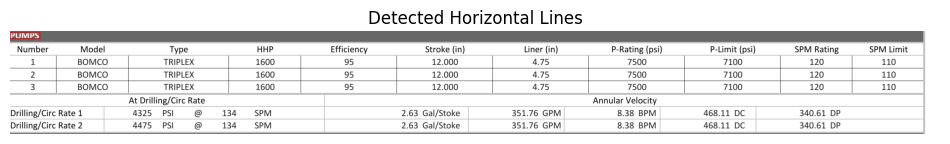

[Row OCR] bbox (x=0, y=4, w=2502, h=16):
PUMPS .
----------------------------------------
[Row OCR] bbox (x=0, y=20, w=2502, h=256):
oEEEEEEEEEEEEEEEEEEEEEEEOEOEOEOEOEOECEOECECECECECECE=~=E$7EEEOEOEEEEE—E>XE—¥==eeeE
Number Model Type HHP Efficiency Stroke {in} Liner (in) P-Rating (psi} P-Limit (psi) SPM Rating SPM Limit
1 BOMCO TRIPLEX 1600 95 12.000 475 7500 7100 120 110
3 BOMCO TRIPLEX 1600 95 12.000 475 7500 7100 120 110
At Drilling/Circ Rate Annular Velocity
Drilling/Circ Rate 1 4325 PSl @ 134 SPM 2.63 Gal/Stoke 351.76 GPM 8.38 BPM 468.11 DC 340.61 DP
Drilling/Circ Rate 2 4475 PSl @ 134 SPM 2.63 Gal/Stoke 351.76 GPM 8.38 BPM 468.11 DC 340.61 DP
----------------------------------------
---- Combined OCR Text Block ----
PUMPS .
oEEEEEEEEEEEEEEEEEEEEEEEOEOEOEOEOEOECEOECECECECECECE=~=E$7EEEOEOEEEEE—E>XE—¥==eeeE
Number Model Type HHP Efficiency Stroke {in} Liner (in) P-Rating (psi} P-Limit (psi) SPM Rating SPM Limit
1 BOMCO TRIPLEX 1600 95 12.000 475 7500 7100 120 110
3 BOMCO TRIPLEX 16

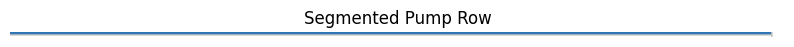

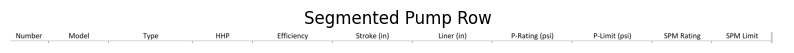

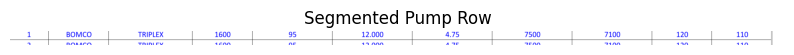

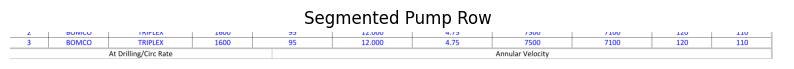

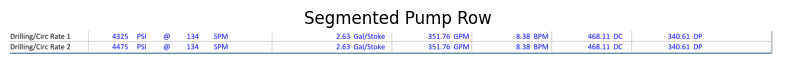

---- Final Pump Lines ----
Number

Model

Type

HHP

Efficiency

Stroke (in)

Liner (in}

P-Rating (psi)

P-Limit (psi)

SPM Rating

SPM Limit

1

BOMCO

TRIPLEX

1600

95

12.000

4.75

7500

7100

120

110

2

BOMCO

TRIPLEX

1600

95

12.000

4.75

7500

7100

120

110

3

BOMCO

TRIPLEX

1600

95

12.000

4.75

7500

7100

120

110

At Drilling/Cire Rate

Annular Velocity

4325 PSI

134

SPM

351.76 GPM

8.38 BPM

468.11 DC

340.61 DP

Drilling/Cire Rate 1

@

2.63 Gal/Stoke

Drilling/Cire Rate 2

4475 PSI

@

134

SPM

2.63 Gal/Stoke

351.76 GPM

8.38 BPM

468.11 DC

340.61 DP
----------------------------------------
----- Pumps Extraction JSON Output -----
{
    "PUMPS": [
        {
            "Number": "1",
            "Model": "BOMCO",
            "Type": "TRIPLEX",
            "HHP": "1600",
            "Efficiency": "95",
            "Stroke (in)": "12.000",
            "Liner (in)": "4.75",
            "P-Rating (psi)": "7500",
            "P-Limit (psi)": "7100",
         

INFO: pumps_extracted.csv saved.
INFO:PipelineRunner:pumps_extracted.csv saved.
INFO: drilling_rates_extracted.csv saved.
INFO:PipelineRunner:drilling_rates_extracted.csv saved.


In [0]:
# import os
# import re
# import cv2
# import json
# import logging
# import numpy as np
# import pytesseract
# from PIL import Image, ImageDraw, ImageFont
# import matplotlib.pyplot as plt
# import pandas as pd

# # ----------------------------
# # Helper: Display image using matplotlib
# # ----------------------------
# def show_image(title, img, size=(10,10), cmap=None):
#     plt.figure(figsize=size)
#     plt.title(title)
#     if cmap:
#         plt.imshow(img, cmap=cmap)
#     else:
#         if len(img.shape)==2:
#             plt.imshow(img, cmap="gray")
#         else:
#             plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
#     plt.axis("off")
#     plt.show()

# # ----------------------------
# # Image Enhancement
# # ----------------------------
# def enhance_image(img: np.ndarray) -> np.ndarray:
#     gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#     eq = cv2.equalizeHist(gray)
#     filtered = cv2.bilateralFilter(eq, d=9, sigmaColor=75, sigmaSpace=75)
#     return filtered

# # ----------------------------
# # Binarization: Otsu & Adaptive
# # ----------------------------
# def binarize_image(img: np.ndarray) -> (np.ndarray, np.ndarray):
#     _, otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
#     adaptive = cv2.adaptiveThreshold(img, 255,
#                                      cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
#                                      cv2.THRESH_BINARY, 15, 10)
#     return otsu, adaptive

# # ----------------------------
# # Multi-PSM OCR on ROI
# # ----------------------------
# def multi_psm_ocr(roi: np.ndarray, debug: bool = False) -> str:
#     enhanced = enhance_image(roi)
#     otsu, adaptive = binarize_image(enhanced)
#     pil_img = Image.fromarray(otsu)
#     psm_modes = ["6", "11"]
#     results = {}
#     for mode in psm_modes:
#         config = f"--psm {mode}"
#         text = pytesseract.image_to_string(pil_img, config=config).strip()
#         lines = [l for l in text.splitlines() if l.strip()]
#         results[mode] = (text, lines)
#         if debug:
#             print(f"[PSM {mode}] {len(lines)} lines:")
#             for l in lines:
#                 print(l)
#             print("-"*40)
#     best_mode = max(psm_modes, key=lambda m: sum(1 for l in results[m][1] if l.strip() and l.strip()[0].isdigit()))
#     if debug:
#         print(f"Selected PSM mode: {best_mode}")
#     return results[best_mode][0]

# # ----------------------------
# # Horizontal Projection Segmentation for Pump ROI
# # ----------------------------
# def segment_rows_via_projection(roi: np.ndarray, debug: bool = False) -> list:
#     gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
#     _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
#     proj = np.sum(binary, axis=1)
#     gap_thresh = np.max(proj) * 0.2
#     gap_indices = np.where(proj < gap_thresh)[0]
#     if len(gap_indices) == 0:
#         pil_img = Image.fromarray(binary)
#         return [pytesseract.image_to_string(pil_img, config="--psm 7").strip()]
#     gap_segments = []
#     start = gap_indices[0]
#     prev = gap_indices[0]
#     for idx in gap_indices[1:]:
#         if idx - prev > 1:
#             gap_segments.append((start, prev))
#             start = idx
#         prev = idx
#     gap_segments.append((start, prev))
#     boundaries = [int((s+e)//2) for s, e in gap_segments]
#     boundaries = [0] + boundaries + [binary.shape[0]]
#     row_texts = []
#     for i in range(len(boundaries)-1):
#         r1, r2 = boundaries[i], boundaries[i+1]
#         if r2 - r1 < 10:
#             continue
#         row_img = roi[r1:r2, :]
#         pil_row = Image.fromarray(row_img)
#         text = pytesseract.image_to_string(pil_row, config="--psm 7").strip()
#         if text:
#             row_texts.append(text)
#         if debug:
#             show_image("Segmented Pump Row", row_img, size=(10,2))
#     return row_texts

# # ----------------------------
# # Split block text into pump and drilling sections
# # ----------------------------
# def split_block_to_sections(block_text: str) -> (list, list):
#     lines = [line.strip() for line in block_text.splitlines() if line.strip()]
#     pump_lines = []
#     drilling_lines = []
#     section = None
#     for line in lines:
#         low = line.lower()
#         if "pumps" in low:
#             section = "pump"
#             continue
#         if "drilling/circ" in low:
#             section = "drilling"
#             drilling_lines.append(line)
#             continue
#         if section == "pump":
#             pump_lines.append(line)
#         elif section == "drilling":
#             drilling_lines.append(line)
#         else:
#             if line and line[0].isdigit():
#                 pump_lines.append(line)
#     return pump_lines, drilling_lines

# # ----------------------------
# # Revised pump-lines parser: if each line is a single token, then group them in sets of 11 tokens.
# # ----------------------------
# def parse_pump_lines(lines: list) -> list:
#     # Remove empty lines and trim
#     trimmed = [line.strip() for line in lines if line.strip()]
#     # Check average number of spaces per line. If very low (e.g. 0), then we assume one token per line.
#     avg_spaces = np.mean([line.count(" ") for line in trimmed]) if trimmed else 0
#     pump_rows = []
#     if avg_spaces < 1:
#         # Assume each line is one token. If the header exists, skip first 11 tokens.
#         tokens = trimmed
#         # If header found, tokens[0] should be "Number" (or close to it)
#         header = []
#         if tokens and re.match(r'number', tokens[0].lower()):
#             header = tokens[:11]
#             tokens = tokens[11:]
#         # Group every 11 tokens into a pump row
#         for i in range(0, len(tokens), 11):
#             group = tokens[i:i+11]
#             if len(group) < 11:
#                 group += [""]*(11-len(group))
#             pump_row = {
#                 "Number": group[0],
#                 "Model": group[1],
#                 "Type": group[2],
#                 "HHP": group[3],
#                 "Efficiency": group[4],
#                 "Stroke (in)": group[5],
#                 "Liner (in)": group[6],
#                 "P-Rating (psi)": group[7],
#                 "P-Limit (psi)": group[8],
#                 "SPM Rating": group[9],
#                 "SPM Limit": group[10]
#             }
#             pump_rows.append(pump_row)
#     else:
#         # Else, assume each line is a full row; split on multiple spaces or pipe.
#         header_found = False
#         for line in trimmed:
#             low = line.lower()
#             if "number" in low and "model" in low:
#                 header_found = True
#                 continue
#             if header_found or (line and line[0].isdigit()):
#                 tokens = re.split(r'\s{2,}|\|', line)
#                 if len(tokens) < 2:
#                     tokens = line.split()
#                 if len(tokens) < 11:
#                     tokens += [""]*(11-len(tokens))
#                 pump_row = {
#                     "Number": tokens[0],
#                     "Model": tokens[1],
#                     "Type": tokens[2],
#                     "HHP": tokens[3],
#                     "Efficiency": tokens[4],
#                     "Stroke (in)": tokens[5],
#                     "Liner (in)": tokens[6],
#                     "P-Rating (psi)": tokens[7],
#                     "P-Limit (psi)": tokens[8],
#                     "SPM Rating": tokens[9],
#                     "SPM Limit": tokens[10]
#                 }
#                 pump_rows.append(pump_row)
#     return pump_rows

# # ----------------------------
# # Parse drilling lines into structured rows
# # ----------------------------
# def parse_drilling_lines(lines: list) -> list:
#     drilling_rows = []
#     for line in lines:
#         tokens = line.split()
#         if len(tokens) < 8:
#             continue
#         rate_id = tokens[2] if tokens[2].isdigit() else ""
#         try:
#             pressure = tokens[3] if len(tokens) > 3 else ""
#             spm = tokens[6] if len(tokens) > 6 else ""
#             gal_stroke = tokens[8] if len(tokens) > 8 else ""
#             gpm = tokens[10] if len(tokens) > 10 else ""
#             bpm = tokens[12] if len(tokens) > 12 else ""
#             dc = tokens[14] if len(tokens) > 14 else ""
#             dp = tokens[16] if len(tokens) > 16 else ""
#         except Exception as e:
#             pressure, spm, gal_stroke, gpm, bpm, dc, dp = ("",)*7
#         drilling_rows.append({
#             "RateID": rate_id,
#             "Pressure": pressure,
#             "SPM": spm,
#             "Gal_Stroke": gal_stroke,
#             "GPM": gpm,
#             "BPM": bpm,
#             "DC": dc,
#             "DP": dp,
#             "Raw": line
#         })
#     return drilling_rows

# # ----------------------------
# # End-to-End Pipeline with Advanced Pump Reassembly
# # ----------------------------
# def main_table_extraction(image_path: str, debug: bool = True) -> dict:
#     img = cv2.imread(image_path)
#     if img is None:
#         raise FileNotFoundError(f"Unable to read image at: {image_path}")
    
#     # Detect rows from full image using morphological ops
#     row_boxes = detect_rows_via_morph_ops(img, debug=debug)
#     row_texts = ocr_on_rows(img, row_boxes, debug=debug)
#     block_text = "\n".join(row_texts)
#     if debug:
#         print("---- Combined OCR Text Block ----")
#         print(block_text)
#         print("-"*60)
    
#     pump_lines, drilling_lines = split_block_to_sections(block_text)
#     if debug:
#         print("---- Initial Pump Section Lines ----")
#         for line in pump_lines:
#             print(line)
#         print("-"*40)
#         print("---- Drilling Section Lines ----")
#         for line in drilling_lines:
#             print(line)
#         print("-"*40)
    
#     # Try to re-segment pump area if necessary.
#     pump_roi = None
#     for i, text in enumerate(row_texts):
#         if "number" in text.lower() and "model" in text.lower():
#             pump_roi = img[row_boxes[i][1]:row_boxes[i][1]+row_boxes[i][3],
#                          row_boxes[i][0]:row_boxes[i][0]+row_boxes[i][2]]
#             break
#     if pump_roi is not None:
#         pump_block = multi_psm_ocr(pump_roi, debug=debug)
#         resegmented = segment_rows_via_projection(pump_roi, debug=debug)
#         # Choose segmentation with more lines.
#         if len(resegmented) > len(pump_block.splitlines()):
#             pump_lines = resegmented
#         else:
#             pump_lines = pump_block.splitlines()
#         if debug:
#             print("---- Final Pump Lines ----")
#             for line in pump_lines:
#                 print(line)
#             print("-"*40)
#     else:
#         if debug:
#             print("No dedicated pump ROI found; using initial pump lines.")

#     pumps = parse_pump_lines(pump_lines)
#     drilling = parse_drilling_lines(drilling_lines)
    
#     return {
#         "PUMPS": pumps,
#         "DrillingCircRates": drilling
#     }

# # ----------------------------
# # Main Runner Class
# # ----------------------------
# class PipelineRunner:
#     def __init__(self, image_path: str, debug: bool = True):
#         self.image_path = image_path
#         self.debug = debug
#         self.logger = logging.getLogger("PipelineRunner")
#         self.logger.setLevel(logging.INFO)
#         if not self.logger.handlers:
#             handler = logging.StreamHandler()
#             handler.setFormatter(logging.Formatter("%(levelname)s: %(message)s"))
#             self.logger.addHandler(handler)
#     def run(self):
#         try:
#             data_json = main_table_extraction(self.image_path, debug=self.debug)
#             print("----- Pumps Extraction JSON Output -----")
#             print(json.dumps(data_json, indent=4))
#             df_pumps = pd.DataFrame(data_json["PUMPS"])
#             df_pumps.to_csv("pumps_extracted.csv", index=False)
#             self.logger.info("pumps_extracted.csv saved.")
#             df_drill = pd.DataFrame(data_json["DrillingCircRates"])
#             df_drill.to_csv("drilling_rates_extracted.csv", index=False)
#             self.logger.info("drilling_rates_extracted.csv saved.")
#         except Exception as e:
#             self.logger.exception("Error during pipeline processing.")

# # ----------------------------
# # Main entry point
# # ----------------------------
# if __name__ == "__main__":
#     logging.basicConfig(level=logging.INFO)
#     image_path = "/dbfs/mnt/mini-proj-dd/cropped_sections/page_1_section_12.png"  # Adjust as needed.
#     runner = PipelineRunner(image_path, debug=True)
#     runner.run()


In [0]:
# import os
# import re
# import cv2
# import json
# import logging
# import numpy as np
# import pytesseract
# import pandas as pd
# from PIL import Image
# import matplotlib.pyplot as plt

# # -----------------------------------------------------------------------------
# # Helper to convert DBFS path to a local path.
# # -----------------------------------------------------------------------------
# def dbfs_to_local_path(dbfs_path: str) -> str:
#     if dbfs_path.startswith("dbfs:/"):
#         return "/dbfs" + dbfs_path.replace("dbfs:", "")
#     return dbfs_path

# # -----------------------------------------------------------------------------
# # Optional helper to display images (only when debug=True)
# # -----------------------------------------------------------------------------
# def show_image(title: str, img, size=(10,10), cmap=None):
#     plt.figure(figsize=size)
#     plt.title(title)
#     if cmap:
#         plt.imshow(img, cmap=cmap)
#     else:
#         if len(img.shape) == 2:
#             plt.imshow(img, cmap="gray")
#         else:
#             plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
#     plt.axis("off")
#     plt.show()

# # -----------------------------------------------------------------------------
# # PumpsPipeline Class: encapsulates all Pumps section processing logic.
# # -----------------------------------------------------------------------------
# class PumpsPipeline:
#     @staticmethod
#     def enhance_image(img: np.ndarray) -> np.ndarray:
#         """Enhance image for OCR: grayscale, histogram equalization, and bilateral filter."""
#         gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#         eq = cv2.equalizeHist(gray)
#         filtered = cv2.bilateralFilter(eq, d=9, sigmaColor=75, sigmaSpace=75)
#         return filtered

#     @staticmethod
#     def binarize_image(img: np.ndarray) -> (np.ndarray, np.ndarray):
#         """Return Otsu and adaptive thresholded images of the input."""
#         _, otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
#         adaptive = cv2.adaptiveThreshold(img, 255, 
#                                          cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
#                                          cv2.THRESH_BINARY, 15, 10)
#         return otsu, adaptive

#     @staticmethod
#     def detect_rows_via_morph_ops(img: np.ndarray, debug: bool = False) -> list:
#         """Detect table row boundaries using morphological operations."""
#         gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#         _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
#         kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
#         morph = cv2.morphologyEx(bw, cv2.MORPH_OPEN, kernel, iterations=2)
#         inv = cv2.bitwise_not(morph)
#         contours, _ = cv2.findContours(inv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#         boxes = []
#         for cnt in contours:
#             x, y, w, h = cv2.boundingRect(cnt)
#             if w > 50 and h < 20:
#                 boxes.append((x, y, w, h))
#         boxes.sort(key=lambda b: b[1])
#         y_coords = []
#         for (x, y, w, h) in boxes:
#             y_coords.append(y)
#             y_coords.append(y+h)
#         y_coords = sorted(list(set(y_coords)))
#         h_img, w_img = gray.shape
#         if y_coords[0] > 5:
#             y_coords.insert(0, 0)
#         if abs(y_coords[-1] - h_img) > 5:
#             y_coords.append(h_img)
#         row_boxes = []
#         for i in range(len(y_coords) - 1):
#             if (y_coords[i+1] - y_coords[i]) >= 10:
#                 row_boxes.append((0, y_coords[i], w_img, y_coords[i+1]-y_coords[i]))
#         if debug:
#             print("Detected", len(row_boxes), "rows via morphology.")
#         return row_boxes

#     @staticmethod
#     def ocr_on_rows(img: np.ndarray, row_boxes: list, debug: bool = False) -> list:
#         """Perform OCR (PSM 6) on each detected row and return list of text results."""
#         texts = []
#         for (x, y, w, h) in row_boxes:
#             roi = img[y:y+h, x:x+w]
#             gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
#             _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
#             pil_roi = Image.fromarray(bw)
#             text = pytesseract.image_to_string(pil_roi, config="--psm 6").strip()
#             texts.append(text)
#         return texts

#     @staticmethod
#     def multi_psm_ocr(roi: np.ndarray, debug: bool = False) -> str:
#         """Run OCR with multiple PSM modes on ROI and return the text from the best mode."""
#         enhanced = PumpsPipeline.enhance_image(roi)
#         otsu, _ = PumpsPipeline.binarize_image(enhanced)
#         pil_img = Image.fromarray(otsu)
#         psm_modes = ["6", "11"]
#         results = {}
#         for mode in psm_modes:
#             config = f"--psm {mode}"
#             text = pytesseract.image_to_string(pil_img, config=config).strip()
#             lines = [l for l in text.splitlines() if l.strip()]
#             results[mode] = (text, lines)
#         best_mode = max(psm_modes, key=lambda m: sum(1 for l in results[m][1] if l.strip() and l.strip()[0].isdigit()))
#         return results[best_mode][0]

#     @staticmethod
#     def segment_rows_via_projection(roi: np.ndarray, debug: bool = False) -> list:
#         """Segment the ROI into rows using horizontal projection."""
#         gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
#         _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
#         proj = np.sum(binary, axis=1)
#         gap_thresh = np.max(proj) * 0.2
#         gap_indices = np.where(proj < gap_thresh)[0]
#         if len(gap_indices) == 0:
#             pil_img = Image.fromarray(binary)
#             return [pytesseract.image_to_string(pil_img, config="--psm 7").strip()]
#         gap_segments = []
#         start = gap_indices[0]
#         prev = gap_indices[0]
#         for idx in gap_indices[1:]:
#             if idx - prev > 1:
#                 gap_segments.append((start, prev))
#                 start = idx
#             prev = idx
#         gap_segments.append((start, prev))
#         boundaries = [int((s+e)//2) for s, e in gap_segments]
#         boundaries = [0] + boundaries + [binary.shape[0]]
#         row_texts = []
#         for i in range(len(boundaries)-1):
#             r1, r2 = boundaries[i], boundaries[i+1]
#             if r2 - r1 < 10:
#                 continue
#             row_img = roi[r1:r2, :]
#             pil_row = Image.fromarray(row_img)
#             text = pytesseract.image_to_string(pil_row, config="--psm 7").strip()
#             if text:
#                 row_texts.append(text)
#         return row_texts

#     @staticmethod
#     def split_block_to_sections(block_text: str) -> (list, list):
#         """Split the block text into pump section lines and drilling section lines."""
#         lines = [line.strip() for line in block_text.splitlines() if line.strip()]
#         pump_lines = []
#         drilling_lines = []
#         section = None
#         for line in lines:
#             low = line.lower()
#             if "pumps" in low:
#                 section = "pump"
#                 continue
#             if "drilling/circ" in low:
#                 section = "drilling"
#                 drilling_lines.append(line)
#                 continue
#             if section == "pump":
#                 pump_lines.append(line)
#             elif section == "drilling":
#                 drilling_lines.append(line)
#             else:
#                 if line and line[0].isdigit():
#                     pump_lines.append(line)
#         return pump_lines, drilling_lines

#     @staticmethod
#     def parse_pump_lines(lines: list) -> list:
#         """
#         Parse pump lines into structured pump rows. If each line contains very few spaces,
#         group tokens in sets of 11; otherwise, split each line on multiple spaces.
#         """
#         trimmed = [l.strip() for l in lines if l.strip()]
#         avg_spaces = np.mean([l.count(" ") for l in trimmed]) if trimmed else 0
#         pump_rows = []
#         if avg_spaces < 1:  # assume each line is one token
#             tokens = trimmed
#             if tokens and re.match(r'number', tokens[0].lower()):
#                 tokens = tokens[11:]
#             for i in range(0, len(tokens), 11):
#                 group = tokens[i:i+11]
#                 if len(group) < 11:
#                     group += [""] * (11 - len(group))
#                 pump_rows.append({
#                     "Number": group[0],
#                     "Model": group[1],
#                     "Type": group[2],
#                     "HHP": group[3],
#                     "Efficiency": group[4],
#                     "Stroke (in)": group[5],
#                     "Liner (in)": group[6],
#                     "P-Rating (psi)": group[7],
#                     "P-Limit (psi)": group[8],
#                     "SPM Rating": group[9],
#                     "SPM Limit": group[10]
#                 })
#         else:
#             header_found = False
#             for line in trimmed:
#                 low = line.lower()
#                 if "number" in low and "model" in low:
#                     header_found = True
#                     continue
#                 if header_found or (line and line[0].isdigit()):
#                     tokens = re.split(r'\s{2,}|\|', line)
#                     if len(tokens) < 2:
#                         tokens = line.split()
#                     if len(tokens) < 11:
#                         tokens += [""] * (11 - len(tokens))
#                     pump_rows.append({
#                         "Number": tokens[0],
#                         "Model": tokens[1],
#                         "Type": tokens[2],
#                         "HHP": tokens[3],
#                         "Efficiency": tokens[4],
#                         "Stroke (in)": tokens[5],
#                         "Liner (in)": tokens[6],
#                         "P-Rating (psi)": tokens[7],
#                         "P-Limit (psi)": tokens[8],
#                         "SPM Rating": tokens[9],
#                         "SPM Limit": tokens[10]
#                     })
#         return pump_rows

#     @staticmethod
#     def parse_drilling_lines(lines: list) -> list:
#         """Parse drilling/circ rate lines into structured rows."""
#         drilling_rows = []
#         for line in lines:
#             tokens = line.split()
#             if len(tokens) < 8:
#                 continue
#             rate_id = tokens[2] if tokens[2].isdigit() else ""
#             try:
#                 pressure = tokens[3] if len(tokens) > 3 else ""
#                 spm = tokens[6] if len(tokens) > 6 else ""
#                 gal_stroke = tokens[8] if len(tokens) > 8 else ""
#                 gpm = tokens[10] if len(tokens) > 10 else ""
#                 bpm = tokens[12] if len(tokens) > 12 else ""
#                 dc = tokens[14] if len(tokens) > 14 else ""
#                 dp = tokens[16] if len(tokens) > 16 else ""
#             except Exception:
#                 pressure, spm, gal_stroke, gpm, bpm, dc, dp = ("",)*7
#             drilling_rows.append({
#                 "RateID": rate_id,
#                 "Pressure": pressure,
#                 "SPM": spm,
#                 "Gal_Stroke": gal_stroke,
#                 "GPM": gpm,
#                 "BPM": bpm,
#                 "DC": dc,
#                 "DP": dp,
#                 "Raw": line
#             })
#         return drilling_rows

#     @staticmethod
#     def process(image_path: str, debug: bool = False) -> (dict, pd.DataFrame):
#         """
#         Main processing method.
#         Reads the image, applies OCR with enhanced techniques, reassembles pump rows, and returns
#         a tuple of (data_json, df) with structured data and a DataFrame.
#         """
#         local_path = dbfs_to_local_path(image_path)
#         img = cv2.imread(local_path)
#         if img is None:
#             raise FileNotFoundError(f"Unable to read image at: {image_path}")
        
#         # Detect rows over the full image.
#         row_boxes = PumpsPipeline.detect_rows_via_morph_ops(img, debug=debug)
#         row_texts = PumpsPipeline.ocr_on_rows(img, row_boxes, debug=debug)
#         block_text = "\n".join(row_texts)
        
#         # Split block text into pump and drilling sections.
#         pump_lines, drilling_lines = PumpsPipeline.split_block_to_sections(block_text)
        
#         # Re-segment pump area if merged.
#         pump_roi = None
#         for i, text in enumerate(row_texts):
#             if "number" in text.lower() and "model" in text.lower():
#                 bx = row_boxes[i]
#                 pump_roi = img[bx[1]:bx[1]+bx[3], bx[0]:bx[0]+bx[2]]
#                 break
#         if pump_roi is not None:
#             pump_block = PumpsPipeline.multi_psm_ocr(pump_roi, debug=debug)
#             resegmented = PumpsPipeline.segment_rows_via_projection(pump_roi, debug=debug)
#             if len(resegmented) > len(pump_block.splitlines()):
#                 final_pump_lines = resegmented
#             else:
#                 final_pump_lines = pump_block.splitlines()
#             pump_lines = final_pump_lines
        
#         pumps = PumpsPipeline.parse_pump_lines(pump_lines)
#         drilling = PumpsPipeline.parse_drilling_lines(drilling_lines)
#         data_json = {"PUMPS": pumps, "DrillingCircRates": drilling}
#         df = pd.DataFrame(pumps)
#         return data_json, df

# # -----------------------------------------------------------------------------
# # Main Runner Class for Integration
# # -----------------------------------------------------------------------------
# class PipelineRunner:
#     def __init__(self, image_path: str, debug: bool = False):
#         self.image_path = image_path
#         self.debug = debug
#         self.logger = logging.getLogger("PipelineRunner")
#         self.logger.setLevel(logging.INFO)
#         if not self.logger.handlers:
#             handler = logging.StreamHandler()
#             handler.setFormatter(logging.Formatter("%(levelname)s: %(message)s"))
#             self.logger.addHandler(handler)
    
#     def run(self):
#         try:
#             data_json, df = PumpsPipeline.process(self.image_path, debug=self.debug)
#             print("----- Pumps Extraction JSON Output -----")
#             print(json.dumps(data_json, indent=4))
#             df.to_csv("pumps_extracted.csv", index=False)
#             self.logger.info("pumps_extracted.csv saved.")
#             # Drilling data CSV
#             df_drill = pd.DataFrame(data_json["DrillingCircRates"])
#             df_drill.to_csv("drilling_rates_extracted.csv", index=False)
#             self.logger.info("drilling_rates_extracted.csv saved.")
#         except Exception as e:
#             self.logger.exception("Error during pipeline processing.")

# # -----------------------------------------------------------------------------
# # Final Integrated Main Pipeline
# # -----------------------------------------------------------------------------
# def main(debug: bool = False):
#     logger = logging.getLogger(__name__)
#     logger.setLevel(logging.INFO)
#     logger.info("Starting main pipeline execution for Pumps section...")
    
#     image_paths = {
#         "PUMPS": "dbfs:/mnt/mini-proj-dd/cropped_sections/page_1_section_12.png"
#         # Other sections can be added here.
#     }
    
#     pipelines = {
#         "PUMPS": PumpsPipeline.process
#     }
    
#     output_folder = dbfs_to_local_path("dbfs:/mnt/mini-proj-dd/final_results")
#     os.makedirs(output_folder, exist_ok=True)
#     aggregated_json = {}
#     aggregated_df = pd.DataFrame()
    
#     for section, img_path in image_paths.items():
#         func = pipelines.get(section)
#         if func is None:
#             logger.info(f"Skipping section '{section}' — pipeline not implemented.")
#             continue
#         try:
#             logger.info(f"Processing section '{section}' from {img_path}...")
#             data_json, df = func(img_path, debug=debug)
#             safe_section = section.replace(" ", "_").lower()
#             json_file = os.path.join(output_folder, f"{safe_section}.json")
#             with open(json_file, "w") as f:
#                 json.dump(data_json, f, indent=4)
#             if df is not None and not df.empty:
#                 aggregated_df = pd.concat([aggregated_df, df], ignore_index=True)
#                 csv_file = os.path.join(output_folder, f"{safe_section}.csv")
#                 df.to_csv(csv_file, index=False)
#             aggregated_json[section] = data_json
#             logger.info(f"Section '{section}' processed successfully.")
#         except Exception as e:
#             logger.exception(f"Error processing section '{section}': {e}")
    
#     agg_json_path = os.path.join(output_folder, "aggregated_data.json")
#     with open(agg_json_path, "w") as f:
#         json.dump(aggregated_json, f, indent=4)
#     agg_csv_path = os.path.join(output_folder, "aggregated_data.csv")
#     aggregated_df.to_csv(agg_csv_path, index=False)
#     logger.info(f"Aggregated results saved to {agg_json_path} and {agg_csv_path}.")
#     print("----- Aggregated JSON Output -----")
#     print(json.dumps(aggregated_json, indent=4))

# # -----------------------------------------------------------------------------
# # Entry Point
# # -----------------------------------------------------------------------------
# if __name__ == "__main__":
#     main(debug=False)


INFO:__main__:Starting main pipeline execution for Pumps section...
INFO:__main__:Processing section 'PUMPS' from dbfs:/mnt/mini-proj-dd/cropped_sections/page_1_section_12.png...
INFO:__main__:Section 'PUMPS' processed successfully.
INFO:__main__:Aggregated results saved to /dbfs/mnt/mini-proj-dd/final_results/aggregated_data.json and /dbfs/mnt/mini-proj-dd/final_results/aggregated_data.csv.


----- Aggregated JSON Output -----
{
    "PUMPS": {
        "PUMPS": [
            {
                "Number": "1",
                "Model": "BOMCO",
                "Type": "TRIPLEX",
                "HHP": "1600",
                "Efficiency": "95",
                "Stroke (in)": "12.000",
                "Liner (in)": "4.75",
                "P-Rating (psi)": "7500",
                "P-Limit (psi)": "7100",
                "SPM Rating": "120",
                "SPM Limit": "110"
            },
            {
                "Number": "2",
                "Model": "BOMCO",
                "Type": "TRIPLEX",
                "HHP": "1600",
                "Efficiency": "95",
                "Stroke (in)": "12.000",
                "Liner (in)": "4.75",
                "P-Rating (psi)": "7500",
                "P-Limit (psi)": "7100",
                "SPM Rating": "120",
                "SPM Limit": "110"
            },
            {
                "Number": "3",
                "Model":